# **1. Introdcution, packages and functions**

In [1]:
# Python Script for Multiplexed FISH data analysis from Marion Bardou et al (2026)
# Related publication : ...
# Date: July 3rd, 2026
# Description: This script analyzes data from a CSV file and generates Analysis of pairwise probability distance distributions from different Drosophila Kenyon cell lines


# **1.1 Packages**

In [2]:
# Import necessary libraries and modules for data analysis
import glob  # For file path matching
import os  # For interacting with the operating system
import numpy as np  # For numerical operations and array handling
import matplotlib.pyplot as plt  # For data visualization
import math  # For mathematical functions
from scipy.optimize import curve_fit  # For fitting curves to data
from scipy.spatial.distance import pdist, squareform  # For distance calculations and transforming data
from scipy.signal import argrelextrema  # For finding relative extrema in data
from scipy.ndimage import gaussian_filter  # For applying a Gaussian filter to data
from scipy.stats import spearmanr, pearsonr
from matplotlib.lines import Line2D  # Import Line2D
from fractions import Fraction
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import pickle


from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import pandas as pd # For reading CSV files
from tqdm import tqdm  # For displaying progress bars
from astropy.table import Table
from collections import OrderedDict
# Get the default color cycle for plotting
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
################################################################################
# Read Marion's data
################################################################################

def READ_mFISH_ECSV(filename, dir):
    """
    Read mFISH data from an ECSV file.

    Parameters:
    - filename (str): The name of the ECSV file.
    - dir (str): The directory containing the file.

    Returns:
    - numpy.ndarray: Numpy array containing mFISH data in micrometers.
    """
    file = os.path.join(dir, filename)
    
    # Read the ECSV file using pandas
    df = pd.read_csv(file, comment='#', delim_whitespace=True, skiprows=19, header=None)
    
    # Extract relevant columns starting from the 3rd column
    data = df.iloc[:, 2:5].apply(pd.to_numeric, errors='coerce').values

    
    # Drop rows with all NaN values
    data = data[~np.all(np.isnan(data), axis=1)]
    # Assuming your data is already in micrometers, no need for additional scaling
    
    return data

################################################################################
# Read mFISH Data
################################################################################

def READ_NPY(filename, dir):
    """
    Read pairwise distances matrix from an NPY file.

    Parameters:
    - filename (str): The name of the NPY file.
    - dir (str): The directory containing the file.

    Returns:
    - numpy.ndarray: Pairwise distances matrix.
    """
    file = os.path.join(dir, filename)
    distances_matrix = np.load(file)
    return distances_matrix

def READ_CSV(filename, dir):
    """
    Read mFISH data from a CSV file and organize it into a 3D matrix.

    Parameters:
    - filename (str): The name of the CSV file.
    - dir (str): The directory containing the file.

    Returns:
    - numpy.ndarray: 3D matrix containing data in micrometers with shape (max_chr_index, 3, 25).
    """
    file_path = f'{dir}/{filename}'
    lines = [ln[:-1].split(',') for ln in open(file_path, 'r')]
    
    # Initialize an empty dictionary to hold the data for each chromosome
    chromosome_data = {}
    
    # Iterate through each line in the CSV file
    for line in lines[1:]:
        if len(line) > 1:
            chr_index = int(float(line[0]))  # Extract chromosome index
            segment_index = int(float(line[1]))  # Extract segment index
            coordinates = [float(val) if val != 'NaN' else np.nan for val in line[2:]]  # Extract coordinates
            
            # Check if chromosome index already exists in the dictionary
            if chr_index not in chromosome_data:
                chromosome_data[chr_index] = []
            
            # Append coordinates to the corresponding chromosome's data
            chromosome_data[chr_index].append(coordinates)
    
    # Initialize an empty 3D matrix to hold the final data
    max_chr_index = max(chromosome_data.keys())
    data_matrix = np.full((max_chr_index, 25, 3), np.nan)
    
    # Iterate through the chromosome data and fill the 3D matrix
    for chr_index, segments in chromosome_data.items():
        segment_count = len(segments)
        for i in range(segment_count):
            if i < 25:
                data_matrix[chr_index - 1, i, :] = segments[i]  # Subtract 1 to convert to 0-based index
    
    return data_matrix

# Example usage:
# data_matrix = READ_CSV("your_filename.csv", "your_directory")

def READ_NPY(filename, dir):
    """
    Read pairwise distances matrix from an NPY file.

    Parameters:
    - filename (str): The name of the NPY file.
    - dir (str): The directory containing the file.

    Returns:
    - numpy.ndarray: Pairwise distances matrix.
    """
    file = os.path.join(dir, filename)
    distances_matrix = np.load(file)
    return distances_matrix

def NonNanPaths(zxys):
    """
    Filter out paths with NaN values.

    Parameters:
    - zxys (numpy.ndarray): 3D array containing  data for multiple cells.

    Returns:
    - numpy.ndarray: Filtered cells containing non-NaN values.
    - list: List of zxys arrays for non-NaN cells.
    """
    
    cells = np.array([c for c in range(len(zxys)) if not True in np.isnan(zxys[c])], dtype=int)
    zxys_ = []
    for c in cells:
        zxys_.append(zxys[c])
    return cells, zxys_

################################################################################
# Fitting Model
################################################################################

# def GAUSSIAN_DISTR(r, R):
#     """
#     Calculate the Gaussian distribution.
# 
#     Parameters:
#     - r (float): The distance.
#     - R (float): The standard deviation.
# 
#     Returns:
#     - float: The Gaussian distribution value.
#     """
#     return 4 * np.pi * r**2 * (3 / (2 * np.pi * R**2))**1.5 * np.exp(-3 * r**2 / (2 * R**2))

def GAUSSIAN_DISTR(r, R):
    r = np.array(r)  # Convert r to a numpy array
    return 4 * np.pi * r**2 * (3 / (2 * np.pi * R**2))**1.5 * np.exp(-3 * r**2 / (2 * R**2))

def TWO_GAUSSIAN_DISTR(r, R1, R2, f):
    """
    Calculate a weighted combination of two Gaussian distributions.

    Parameters:
    - r (float): The distance.
    - R1 (float): Standard deviation for the first Gaussian.
    - R2 (float): Standard deviation for the second Gaussian.
    - f (float): Weighting factor for the first Gaussian.

    Returns:
    - float: The combined Gaussian distribution value.
    """
    return f * GAUSSIAN_DISTR(r, R1) + (1 - f) * GAUSSIAN_DISTR(r, R2)

def TWO_GAUSSIAN_DISTR_FIXED_R(r, R1, R2, f):
    """
    Calculate a weighted combination of two Gaussian distributions with fixed R1 and R2  that come from a large sample (Non-Kenyon cells) where the gene is not expressed.

    Parameters:
    - r (float): The distance.
    - f (float): Weighting factor for the first Gaussian.
    - R1 (float): Standard deviation for the first Gaussian.
    - R2 (float): Standard deviation for the second Gaussian.

    Returns:l // 2
    - float: The combined Gaussian distribution value.
    """
    return f * GAUSSIAN_DISTR(r, R1) + (1 - f) * GAUSSIAN_DISTR(r, R2)

def power_function(x, a, b):
    epsilon = 1e-10
    x = np.maximum(x, epsilon)  # Ensure x is not zero or negative
    return a * (x**b)


def save_dict_to_pickle(data_dict, filename):
    with open(filename, 'wb') as f:
        pickle.dump(data_dict, f)
        
def load_dict_from_pickle(filename):
    with open(filename, 'rb') as f:
        data_dict = pickle.load(f)
    return data_dict
        
################################################################################
# Interpolation 
################################################################################

def interp1dnan(A): 
    """
    Interpolate NaN values in an array using linear interpolation.

    Parameters:
    - A (numpy.ndarray): Array containing NaN values.

    Returns:
    - numpy.ndarray: Array with NaN values interpolated.
    """
    
    A_ = np.array(A)
    missing = np.isnan(A)
    nonmissing = ~missing
    xp = np.where(nonmissing)[0]
    fp = A[nonmissing]
    x = np.where(missing)[0]
    A_[missing] = np.interp(x, xp, fp)
    return A_

def plot_map(zxy, interpolate=True):
    """
    Plot a heatmap of distances between points.

    Parameters:
    - zxy (numpy.ndarray): Array of 3D coordinates.

    Returns:
    - None
    """
    zxy_ = np.array(zxy)
    if interpolate:
        zxy_ = np.array(list(map(interp1dnan, zxy.T))).T
        bad = np.where(np.isnan(zxy[:, 0]))[0]
    mat_ = squareform(pdist(zxy_))
    mat_[bad, bad] = np.nan
    plt.imshow(-mat_, interpolation='nearest', cmap='seismic', vmin=-1000, vmax=0)

def interpolate_zxy(zxy, interpolate=True):
    """
    Interpolate NaN values in 3D coordinates.

    Parameters:
    - zxy (numpy.ndarray): 3D coordinate data.

    Returns:
    - numpy.ndarray: Interpolated 3D coordinates.
    """
    zxy_ = np.array(zxy)
    if interpolate:
        zxy_ = np.array(list(map(interp1dnan, zxy.T))).T
    return zxy_

def INTERPOLATE_ZXY(ZXY):
    """
    Interpolate NaN values in 3D coordinate data for multiple cells.

    Parameters:
    - ZXY (numpy.ndarray): 3D coordinate data for multiple cells.

    Returns:
    - numpy.ndarray: Interpolated 3D coordinate data.
    """
    ncells, ntags, ncoor = ZXY.shape
    ZXY_ = np.zeros((ncells, ntags, ncoor))
    for cell in range(ncells):
        try:
            ZXY_[cell] = interpolate_zxy(ZXY[cell])
        except:
            print(f'Problem could not be resolved for cell {cell}')
    return ZXY_

def plot_matrices(RESULTS, cell_lines=None):
    # Define the color points for the custom colormap
    colors = [(1, 0.05, 0.05), (0.99, 0.99, 0.99), (0.027, 0.047, 0.50)]

    # Create a custom colormap with the adjusted colors
    n_bins = 256
    cmap_name = "custom_colormap"
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

    # If cell_lines is not specified, use all cell lines in the dictionary
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())

    for cell_line in cell_lines:
        name = RESULTS[cell_line]['name']
        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']

        # Mask the matrices
        upper_triangle = np.triu(fr_matrix)
        upper_triangle[np.tril_indices_from(upper_triangle)] = np.nan

        lower_triangle = np.tril(1 - fr_matrix)
        lower_triangle[np.triu_indices_from(lower_triangle)] = np.nan

        fig, axs = plt.subplots(1, 3, figsize=(15, 15))
        fig.suptitle(f'{name}', y=0.75, fontsize=20, fontweight='bold')  # shared title for both subplots, adjusted position

        # Subplot 1: R_alpha Matrix
        im1 = axs[0].imshow(Re1_matrix, interpolation='nearest', cmap=custom_cmap, vmin=0, vmax=1.0)
        axs[0].set_title(r'$R_{L}$ Matrix', fontsize=18)
        axs[0].set_xlabel('Tag number', fontsize=16)
        axs[0].set_ylabel('Tag number', fontsize=16)
        axs[0].tick_params(labelsize=16)

        # Subplot 2: R_beta Matrix
        im2 = axs[1].imshow(Re2_matrix, interpolation='nearest', cmap=custom_cmap, vmin=0, vmax=1.0)
        axs[1].set_title(r'$R_{\beta}$ Matrix', fontsize=18)
        axs[1].set_xlabel('Tag number', fontsize=16)
        axs[1].set_ylabel('Tag number', fontsize=16)
        axs[1].tick_params(labelsize=16)

        # Subplot 3: F_alpha Matrix
        im3 = axs[2].imshow(fr_matrix, interpolation='nearest', cmap=custom_cmap, vmin=0, vmax=1)
        axs[2].set_title(r'$f_{L}$ Matrix', fontsize=18)
        axs[2].set_xlabel('Tag number', fontsize=16)
        axs[2].set_ylabel('Tag number', fontsize=16)
        axs[2].tick_params(labelsize=16)

        # Add colorbar for each subplot
        cax = fig.add_axes([0.15, 0.85, 0.7, 0.03])  # [left, bottom, width, height]
        cbar = fig.colorbar(im1, cax=cax, orientation='horizontal')
        cbar.set_label(r"$R\ (\mu m)\ or\ f_L$", fontsize=18)
        cbar.ax.tick_params(labelsize=16)

        plt.tight_layout()
        plt.show()
        
#Plot matrices for fixed R1 and R2: 

def plot_matrices_fixed_R(data_dict, cell_lines=None):
    # Define the color points for the custom colormap
    colors = [(1, 0.05, 0.05), (0.99, 0.99, 0.99), (0.027, 0.047, 0.50)]

    # Create a custom colormap with the adjusted colors
    n_bins = 256
    cmap_name = "custom_colormap"
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

    # If cell_lines is not specified, use all cell lines in the dictionary
    if cell_lines is None:
        cell_lines = list(data_dict.keys())
    else:
        cell_lines = [cell_line for cell_line in cell_lines if cell_line in data_dict]

    for cell_line in cell_lines:
        name = data_dict[cell_line]['name']
        # Get the distance matrix for the current cell line
        dm = data_dict[cell_line]['distmat']
        bc_name = data_dict[cell_line]['bc_names']
        
        # Use the pre-calculated matrices to fit the distributions
        Re1_matrix_fixed = data_dict[cell_line]['Re1_matrix_fixed']
        Re2_matrix_fixed = data_dict[cell_line]['Re2_matrix_fixed']
        fr_matrix_fixed = data_dict[cell_line]['fr_matrix_fixed']
        

        
        # Mask the matrices
        upper_triangle = np.triu(fr_matrix_fixed)
        upper_triangle[np.tril_indices_from(upper_triangle)] = np.nan

        lower_triangle = np.tril(1 - fr_matrix_fixed)
        lower_triangle[np.triu_indices_from(lower_triangle)] = np.nan

        fig, axs = plt.subplots(1, 3, figsize=(15, 15))
        fig.suptitle(f'{name}', y=0.75, fontsize=20, fontweight='bold')  # shared title for both subplots, adjusted position

        # Subplot 1: R_alpha Matrix
        im1 = axs[0].imshow(Re1_matrix_fixed, interpolation='nearest', cmap=custom_cmap, vmin=0, vmax=1.0)
        axs[0].set_title(r'fixed $R_{L}$ Matrix', fontsize=18)
        axs[0].set_xlabel('Tag number', fontsize=16)
        axs[0].set_ylabel('Tag number', fontsize=16)
        axs[0].tick_params(labelsize=16)

        # Subplot 2: R_beta Matrix
        im2 = axs[1].imshow(Re2_matrix_fixed, interpolation='nearest', cmap=custom_cmap, vmin=0, vmax=1.0)
        axs[1].set_title(r'fixed $R_{\beta}$ Matrix', fontsize=18)
        axs[1].set_xlabel('Tag number', fontsize=16)
        axs[1].set_ylabel('Tag number', fontsize=16)
        axs[1].tick_params(labelsize=16)
        
        # Subplot 3: F_alpha Matrix
        im3 = axs[2].imshow(fr_matrix_fixed, interpolation='nearest', cmap=custom_cmap, vmin=0, vmax=1)
        axs[2].set_title(r'$f_{L}$ Matrix', fontsize=18)
        axs[2].set_xlabel('Tag number', fontsize=16)
        axs[2].set_ylabel('Tag number', fontsize=16)
        axs[2].tick_params(labelsize=16)
        
        # Add colorbar for each subplot
        cax = fig.add_axes([0.15, 0.85, 0.7, 0.03])  # [left, bottom, width, height]
        cbar = fig.colorbar(im1, cax=cax, orientation='horizontal')
        cbar.set_label(r"$R\ (\mu m)\ ou\ f_L$", fontsize=18)
        cbar.ax.tick_params(labelsize=16)
        
        plt.tight_layout()
        plt.show()
        
def power_function(x, a, b):
    epsilon = 1e-10  # Small constant to avoid issues with zero values
    return a * ((x + epsilon)**b)

Mean square distances and diffusion constant


In [4]:
# Define the sliding_window_diffusion_constant function
def sliding_window_diffusion_constant(msd, window_size, delta_t=1, dimension=3):
    num_points = len(msd)
    diffusion_constants = []

    for i in range(num_points - window_size):
        t = np.arange(i, i + window_size) * delta_t
        valid_indices = np.where(~np.isnan(msd[i:i + window_size]))[0]  # Find non-NaN indices
        if len(valid_indices) >= 2:  # Ensure at least 2 valid indices for fitting
            slope, _ = np.polyfit(t[valid_indices], msd[i:i + window_size][valid_indices], 1)
            D = slope / (2 * dimension)
            diffusion_constants.append(D)

    return diffusion_constants

def plot_msd_diffusion_constant(RESULTS, cell_lines_order, window_size=5):
    # Create subplots for sNPF cell lines
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.ravel()  # Flatten axes for easier iteration

    for ax, (line_name, color) in zip(axes, cell_lines_order):
        
        # Plotting the MSD on the primary y-axis
        ax.plot(RESULTS[line_name]['MSD'], color=color, label=f'{line_name}')
        ax.set_ylabel('MSD')
        ax.set_ylim(0, 1.5)
        
        # Create a secondary y-axis for the diffusion constant
        ax2 = ax.twinx()
        ax2.plot(np.arange(window_size, len(RESULTS[line_name]['MSD'])), RESULTS[line_name]['D_values'], ':', label=f'Diffusion Constant (window={window_size})', color=color)
        ax2.set_ylabel('Diffusion Constant')
        ax2.set_ylim(0, max(RESULTS[line_name]['D_values']) * 1.2) # adjust the scaling factor as needed
        
        ax.set_title(line_name)
        ax.legend(loc='upper left')

    axes[-1].set_visible(False)  # Hide the last subplot if not needed
    axes[-2].set_xlabel('Tag')   # Setting x-label for the bottom left subplot
    axes[-3].set_xlabel('Tag')   # Setting x-label for the bottom middle subplot
    plt.tight_layout()            # Adjusting the space between plots
    plt.show()
    
def MSD(zxys, window_size,i_ref):
    ii = np.linspace(0, zxys.shape[0] - 1, zxys.shape[0], dtype=int)
    x_list = []
    y_list = []
    z_list = []

    for i in ii:
        x_list.append((((zxys[i] - zxys[i][0]).T)[0] / 1))
        y_list.append((((zxys[i] - zxys[i][0]).T)[1] / 1))
        z_list.append((((zxys[i] - zxys[i][0]).T)[2] / 1))

    # Filter nan values
    filtered_x_list = []
    filtered_y_list = []
    filtered_z_list = []

    # Remove nan values from the list
    for sublist_x, sublist_y, sublist_z in zip(x_list, y_list, z_list):
        if np.isnan(sublist_x[0]) or np.isnan(sublist_y[0]) or np.isnan(sublist_z[0]):
            continue

        filtered_sublist_x = []
        filtered_sublist_y = []
        filtered_sublist_z = []
        previous_value_x = None
        previous_value_y = None
        previous_value_z = None

        for x, y, z in zip(sublist_x, sublist_y, sublist_z):
            if np.isnan(x):
                if previous_value_x is None:
                    filtered_sublist_x.append(np.nan)
                else:
                    filtered_sublist_x.append(previous_value_x)
            else:
                filtered_sublist_x.append(x)
                previous_value_x = x

            if np.isnan(y):
                if previous_value_y is None:
                    filtered_sublist_y.append(np.nan)
                else:
                    filtered_sublist_y.append(previous_value_y)
            else:
                filtered_sublist_y.append(y)
                previous_value_y = y

            if np.isnan(z):
                if previous_value_z is None:
                    filtered_sublist_z.append(np.nan)
                else:
                    filtered_sublist_z.append(previous_value_z)
            else:
                filtered_sublist_z.append(z)
                previous_value_z = z

        filtered_x_list.append(filtered_sublist_x)
        filtered_y_list.append(filtered_sublist_y)
        filtered_z_list.append(filtered_sublist_z)

    filtered_x_list = np.array(filtered_x_list)
    filtered_y_list = np.array(filtered_y_list)
    filtered_z_list = np.array(filtered_z_list)

    num_samples, num_points = filtered_x_list.shape  # Get the dimensions of the matrices
    squared_displacements = np.zeros((num_samples, num_points ))

    # Compute MSD for each sample
    
    for sample in range(num_samples):
        x_initial = filtered_x_list[sample, i_ref]  # Initial x-coordinate
        y_initial = filtered_y_list[sample, i_ref]  # Initial y-coordinate
        z_initial = filtered_z_list[sample, i_ref]  # Initial z-coordinate

        for t in range(0, num_points):
            squared_displacements[sample, t ] = (filtered_x_list[sample, t] - x_initial) ** 2 + \
                                                  (filtered_y_list[sample, t] - y_initial) ** 2 + \
                                                  (filtered_z_list[sample, t] - z_initial) ** 2

    # Integrate MSD and std_MSD into the RESULTS dictionary
    average_msd = np.mean(squared_displacements, axis=0)
    std_msd = np.std(squared_displacements, axis=0)
    
        # Compute the diffusion constants
    D_values = sliding_window_diffusion_constant(average_msd, window_size)
    return average_msd, std_msd, D_values

# Define the power-law MSD model
def power_law_msd(t, K, alpha):
    return K * t ** alpha

In [5]:
# plot the goodness of fit 

def plot_r2_scores(RESULTS, cell_lines, ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys()) 
    # Determine the type of tissues (sNPF or rut) based on the dictionary name

    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)

        
    else:
        raise ValueError('Invalid dictionary')

    lines = 3
    columns = 3
    fig, axs = plt.subplots(lines , columns , figsize=(columns*5, lines*3.5), sharex='col', sharey='row')
    # Set the title for the entire figure
    plt.suptitle(f'{tissues_type}', fontsize=20, fontweight='bold', y=1.05)
    for cl, cell_line in enumerate(cell_lines):
        
        name = RESULTS[cell_line]['name']
        genomic_position = RESULTS[cell_line]['genomic_dist']
        bc_position = RESULTS[cell_line]['bc_position']

        # Use specified color or default to the color cycle
        color = RESULTS[cell_line]['color']  
        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']
        bc_position = RESULTS[cell_line]['bc_position']
        genomic_dist = RESULTS[cell_line]['genomic_dist']
        
        DRe1_matrix = RESULTS[cell_line]['DRe1_matrix']
        DRe2_matrix = RESULTS[cell_line]['DRe2_matrix']
        Dfr_matrix = RESULTS[cell_line]['Dfr_matrix']
        
        R_matrix = RESULTS[cell_line]['Unique_R']
        DR_matrix = RESULTS[cell_line]['DUnique_R']
        
        # Calculate the mean for each i and i + x pair
        fa = fr_matrix[ref_bc, :] 
        Re1 = Re1_matrix[ref_bc, :]
        Re2 = Re2_matrix[ref_bc, :]
        
        Dfa = Dfr_matrix[ref_bc, :]
        DRe1 = DRe1_matrix[ref_bc, :]
        DRe2 = DRe2_matrix[ref_bc, :]
        
        R_gauss = R_matrix[ref_bc, :]
        DR_gauss = DR_matrix[ref_bc, :]
        
        
        bc_color = RESULTS[cell_line]['bc_color']
        
        
        bc_position = [(bc_position[ref_bc]-i)/1000 for i in bc_position]
        
        r2_two_phases_matrix = RESULTS[cell_line]['R_squared_matrix']
        r2_gauss_matrix = RESULTS[cell_line]['R_squared_gauss_matrix']
        r2_two_phases = r2_two_phases_matrix[ref_bc, :]
        r2_gauss = r2_gauss_matrix[ref_bc, :]
        
        # Define upper and lower bounds for Re1 and Re2
        upper_Re1 = Re1 + DRe1
        lower_Re1 = Re1 - DRe1
        upper_Re2 = Re2 + DRe2
        lower_Re2 = Re2 - DRe2
        
        upper_R = R_gauss + DR_gauss
        lower_R = R_gauss - DR_gauss
        
        condition = ((lower_Re1 >= lower_Re2) & (upper_Re1 <= upper_Re2)) | ((lower_Re2 >= lower_Re1) & (upper_Re2 <= upper_Re1)) | (((lower_R >= lower_Re1) & (upper_R <= upper_Re1 )) | ((R_gauss >= lower_Re2) & (R_gauss <= upper_Re2))) | (r2_two_phases - 0.05 < r2_gauss ) | (Dfa > 1/5)

        f_condition = Dfa>0.1

        ax = axs[cl // columns, cl % columns]

        ax.plot(bc_position, r2_two_phases, linewidth=2, color='tab:purple', label='deux états')
        ax.plot(bc_position, r2_gauss, linewidth=2, color='tab:green', label='un état')
        # ax.plot(bc_position, np.abs(R_gauss-Re2), linewidth=2, color='tab:blue', label='R2 diff')
        # ax.plot(bc_position, np.abs(R_gauss-Re1), linewidth=2, color='tab:red', label='R1 diff')
        ax.set_title(name, fontsize=18)  # Add this line to set the subtitle. Adjust the fontsize as needed.
        # ax.fill_between(bc_position, 0, 1, where= r2_two_phases - 0.05 < r2_gauss, color='tab:green', alpha=0.1)
        ax.fill_between(bc_position, 0, 1, where=condition, color='tab:green', alpha=0.1)
        # ax.fill_between(bc_position, 0, 1, where=f_condition, color='tab:red', alpha=0.1)
        

        # ax.fill_between(bc_position, 0, 1, where=r2_two_phases+0.07 > r2_gauss, color='tab:blue', alpha=0.1)
        ax.bar(bc_position,0.05,width=2, color=bc_color, linewidth=3.5, alpha=0.5)
        ax.legend(fontsize=14, loc='best')
        ax.set_xscale('linear')
        ax.tick_params(axis='both', which='both', labelsize=18)
        ax.set_ylim(0, 1)
        if cl/lines > 1:
            ax.set_xlabel('Distance génomique (kb)', fontsize=18)
            # ax.set_xticks([])
        else:
            ax.set_xlabel('Distance génomique (kb)', fontsize=18)

        if cl == 0 or cl == 3:
            ax.set_ylabel(r"$\chi$", fontsize=18, rotation=-0, rotation_mode='anchor')
    plt.tight_layout(pad=0.5)
    plt.show()

In [6]:
# Update the plot_alpha_fraction function
def plot_alpha_fraction(RESULTS, cell_lines,ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys()) 
    # Determine the type of tissues (sNPF or rut) based on the dictionary name

    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)

        
    else:
        raise ValueError('Invalid dictionary')

    lines = 3
    columns = 3
    fig, axs = plt.subplots(lines , columns , figsize=(columns*5, lines*3.5), sharex='col', sharey='row')
    # Set the title for the entire figure
    plt.suptitle(f'{tissues_type}', fontsize=20, fontweight='bold', y=1.05)
    for cl, cell_line in enumerate(cell_lines):
        name = RESULTS[cell_line]['name']
        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']
        bc_position = RESULTS[cell_line]['bc_position']
        genomic_dist = RESULTS[cell_line]['genomic_dist']
        
        DRe1_matrix = RESULTS[cell_line]['DRe1_matrix']
        DRe2_matrix = RESULTS[cell_line]['DRe2_matrix']
        Dfr_matrix = RESULTS[cell_line]['Dfr_matrix']
        
        R_matrix = RESULTS[cell_line]['Unique_R']
        DR_matrix = RESULTS[cell_line]['DUnique_R']
        
        # Use specified color or default to the color cycle
        color = RESULTS[cell_line]['color']  
        
        bc_color = RESULTS[cell_line]['bc_color']

        # Calculate the mean for each i and i + x pair
        fa = fr_matrix[ref_bc, :] 
        Re1 = Re1_matrix[ref_bc, :]
        Re2 = Re2_matrix[ref_bc, :]
        
        Dfa = Dfr_matrix[ref_bc, :]
        DRe1 = DRe1_matrix[ref_bc, :]
        DRe2 = DRe2_matrix[ref_bc, :]
        
        R_gauss = R_matrix[ref_bc, :]
        DR_gauss = DR_matrix[ref_bc, :]
        
        other_bc = [i for i in range(Re1_matrix.shape[0]) if i != ref_bc]
        fa_other = np.mean(fr_matrix[other_bc, :],axis=0)


        r2_two_phases_matrix = RESULTS[cell_line]['R_squared_matrix']
        r2_gauss_matrix = RESULTS[cell_line]['R_squared_gauss_matrix']
        r2_two_phases = r2_two_phases_matrix[ref_bc, :]
        r2_gauss = r2_gauss_matrix[ref_bc, :]
        
        # Define upper and lower bounds for Re1 and Re2
        upper_Re1 = Re1 + DRe1
        lower_Re1 = Re1 - DRe1
        upper_Re2 = Re2 + DRe2
        lower_Re2 = Re2 - DRe2
        
        upper_R = R_gauss + DR_gauss
        lower_R = R_gauss - DR_gauss
        
        condition = ((lower_Re1 >= lower_Re2) & (upper_Re1 <= upper_Re2)) | ((lower_Re2 >= lower_Re1) & (upper_Re2 <= upper_Re1)) | (((lower_R >= lower_Re1) & (upper_R <= upper_Re1 )) | ((R_gauss >= lower_Re2) & (R_gauss <= upper_Re2))) | (r2_two_phases - 0.05 < r2_gauss ) | (Dfa > 1/5)

        bc_position = [(bc_position[ref_bc]-i)/1000 for i in bc_position]

        # Plot the data
        ax = axs[cl // columns, cl % columns]
        ax.plot(bc_position,fa, linewidth=2, color=color, label=ref_key )
        ax.errorbar(bc_position, fa, yerr=Dfa, fmt='o', color='k', ecolor='k', capsize=4, capthick=2)

        # ax.plot(bc_position, [np.mean(fa[other_bc])]*len(bc_position), linewidth=1, linestyle=':', color='k', label='Mean')
        ax.plot(bc_position, fa_other, linewidth=1, linestyle=':', color='k', label=r'$\langle vs. autres \rangle$')
        ax.set_title(name, fontsize=18)  # Add this line to set the subtitle. Adjust the fontsize as needed.


        
        ax.fill_between(bc_position, Re1-DRe1, Re1+DRe1, color='tab:red', alpha=0.1)
        ax.fill_between(bc_position, Re2-DRe2, Re2+DRe2, color='tab:blue', alpha=0.1)
        ax.fill_between(bc_position, R_gauss-DR_gauss, R_gauss+DR_gauss, color='tab:green', alpha=0.1)
        
        # for i, item in enumerate(bc_color):
        ax.bar(bc_position,0.05,width=2, color=bc_color, linewidth=3.5, alpha=0.5)
        # Set the title for each subplot
        ax.legend(fontsize=14, loc='best')

        ax.set_xscale('linear')

        # Set the ticks font size
        ax.tick_params(axis='both', which='both', labelsize=18)
        ax.set_ylim(0, 1)

        # if cl/lines > 1:
        ax.set_xlabel('$\Delta s (kb)$', fontsize=18)
        # ax.set_xticksla
            # ax.set_xticks([])
       # / else:
            # ax.set_xlabel()

        if cl == 0 or cl == 3:
            ax.set_ylabel(r"$f_L$", fontsize=18, rotation=-0, rotation_mode='anchor', labelpad=10)

    plt.tight_layout(pad=0.5)
    plt.show()


In [7]:
def plot_alpha_fraction_fixed(RESULTS,ref_cell_line, cell_lines,ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())
        
    # Determine the type of tissues (sNPF or rut) based on the dictionary name

    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)
    else:
        raise ValueError('Invalid dictionary')
    
    lines = 3
    columns = 3
    fig, axs = plt.subplots(lines , columns , figsize=(columns*5, lines*3.5), sharex='col', sharey='row')
    # Set the title for the entire figure
    plt.suptitle(f'{tissues_type}', fontsize=20, fontweight='bold', y=1.05)

    for cl, cell_line in enumerate(cell_lines):
        name = RESULTS[cell_line]['name']
        print(name)
        bc_position = RESULTS[cell_line]['bc_position']

        # Use specified color or default to the color cycle
        color = RESULTS[cell_line]['color']
        bc_color = RESULTS[cell_line]['bc_color']
        bc_position = [(bc_position[ref_bc]-i)/1000 for i in bc_position]

        # Plot the data for non-Kenyon cells
        Re1_matrix_ref = RESULTS[ref_cell_line]['Re1_matrix']
        R2_matrix_ref = RESULTS[ref_cell_line]['Re2_matrix']
        fr_matrix_ref = RESULTS[ref_cell_line]['fr_matrix']
        
        DRe1_matrix_ref = RESULTS[ref_cell_line]['DRe1_matrix']
        DRe2_matrix_ref = RESULTS[ref_cell_line]['DRe2_matrix']
        Dfr_matrix_ref = RESULTS[ref_cell_line]['Dfr_matrix']
        
        fa_ref = fr_matrix_ref[ref_bc, :]
        Re1_ref = Re1_matrix_ref[ref_bc, :]
        Re2_ref = R2_matrix_ref[ref_bc, :]

        Re1_matrix_fixed = RESULTS[cell_line]['Re1_matrix_fixed']
        Re2_matrix_fixed = RESULTS[cell_line]['Re2_matrix_fixed']
        fr_matrix_fixed = RESULTS[cell_line]['fr_matrix_fixed']
        fa_fixed = fr_matrix_fixed[ref_bc, :]

        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']
        fa = fr_matrix[ref_bc, :]
        
        DRe1_matrix_fixed = RESULTS[cell_line]['DRe1_matrix_fixed']
        DRe2_matrix_fixed = RESULTS[cell_line]['DRe2_matrix_fixed']
        Dfr_matrix_fixed = RESULTS[cell_line]['Dfr_matrix_fixed']
        Dfa_fixed = Dfr_matrix_fixed[ref_bc, :]
        
        
        
        
        other_bc = [i for i in range(Re1_matrix.shape[0]) if i != ref_bc]
        
        ax = axs[cl // columns, cl % columns]
        
        # ax.plot(bc_position, fa_ref, linewidth=2, linestyle=':', color='tab:gray')
        # ax.plot(bc_position, fa, linewidth=2, color=color, label=name)
        ax.plot(bc_position, fa_fixed, linewidth=2, linestyle='-.', color=color)
        ax.errorbar(bc_position, fa_fixed, yerr=Dfa_fixed, fmt='o', color='k', ecolor='k', capsize=4, capthick=2)
        ax.set_title(name, fontsize=18)  
        
        # ax.plot(bc_position, [np.mean(fa_fixed[other_bc])]*len(bc_position), linewidth=1, linestyle=':', color='k', label='Mean')


        ax.fill_between(bc_position, Re1_matrix_fixed[ref_bc, :]-DRe1_matrix_fixed[ref_bc, :], Re1_matrix_fixed[ref_bc, :]+DRe1_matrix_fixed[ref_bc, :], color='tab:red', alpha=0.1)
        ax.fill_between(bc_position, Re2_matrix_fixed[ref_bc, :]-DRe2_matrix_fixed[ref_bc, :], Re2_matrix_fixed[ref_bc, :]+DRe2_matrix_fixed[ref_bc, :], color='tab:blue', alpha=0.1)

        ax.bar(bc_position,0.05,width=2, color=bc_color, linewidth=3.5, alpha=1)

        ax.set_xscale('linear')
        
        ax.set_ylim(0, 1)
        ax.legend(fontsize=14, loc='best')
        
        # if cl/lines > 1:
        ax.set_xlabel('$\Delta s (kb)$', fontsize=18)
        ax.tick_params(axis='both', which='both', labelsize=18)
        if cl % columns == 0:
            ax.set_ylabel(r"$f_{L}$", fontsize=18, rotation=-0, rotation_mode='anchor', labelpad=10)
            ax.tick_params(axis='both', which='both', labelsize=18)
    
    plt.tight_layout(pad=0.5)
    # legend_labels = ['Reference','cell line with free radii', 'cell line with fixed radii', 'Radii range']
    handles = []
    # for i, label in enumerate(legend_labels):
    #     if i < 3:
    #         handles.append(Line2D([0], [0], linestyle=':' if i == 0 else '-' if i == 1 else '--' if i ==2 else None,  color='tab:gray', label=label))
    #     else:
    #         handles.append(mpatches.Patch(color='tab:gray', alpha=0.1, label=label))
    # fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=18, bbox_to_anchor=(0.5, 0 - 0.1))
    plt.show()

In [8]:
def plot_alpha_scores(RESULTS,ref_cell_line, cell_lines,ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())
        
    # Determine the type of tissues (sNPF or rut) based on the dictionary name

    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)
    else:
        raise ValueError('Invalid dictionary')
    
    columns = 3
    lines = 3

    # Calculate the number of rows needed based on the number of cell lines


    fig, axs = plt.subplots(lines, columns, figsize=(columns*5, lines*3.5), sharex='col', sharey='row')
    # Set the title for the entire figure
    plt.suptitle(f'{tissues_type}', fontsize=20, fontweight='bold', y=1.05)


    Re1_matrix_ref = RESULTS[ref_cell_line]['Re1_matrix']
    Re2_matrix_ref = RESULTS[ref_cell_line]['Re2_matrix']
    fr_matrix_ref = RESULTS[ref_cell_line]['fr_matrix']

    DRe1_matrix_ref = RESULTS[ref_cell_line]['DRe1_matrix']
    DRe2_matrix_ref = RESULTS[ref_cell_line]['DRe2_matrix']
    Dfr_matrix_ref = RESULTS[ref_cell_line]['Dfr_matrix']

    # For comparison we take NK cells as reference
    Re1_matrix_NK = RESULTS[ref_cell_line]['Re1_matrix_fixed']
    Re2_matrix_NK = RESULTS[ref_cell_line]['Re2_matrix_fixed']
    fr_matrix_NK = RESULTS[ref_cell_line]['fr_matrix_fixed']

    DRe1_matrix_NK = RESULTS[ref_cell_line]['DRe1_matrix_fixed']
    DRe2_matrix_NK = RESULTS[ref_cell_line]['DRe2_matrix_fixed']
    Dfr_matrix_NK = RESULTS[ref_cell_line]['Dfr_matrix_fixed']


    for cl, cell_line in enumerate(cell_lines):
        name = RESULTS[cell_line]['name']
        bc_position = RESULTS[cell_line]['bc_position']

        # Use specified color or default to the color cycle
        color = RESULTS[cell_line]['color']
        bc_color = RESULTS[cell_line]['bc_color']
        bc_position = [(i-bc_position[0])/1000 for i in bc_position]


        Re1_ref = Re1_matrix_ref[ref_bc, :]
        Re2_ref = Re2_matrix_ref[ref_bc, :]
        fa_ref = fr_matrix_ref[ref_bc, :]
        Dfa_ref = Dfr_matrix_ref[ref_bc, :]

        Re1_NK = Re1_matrix_NK[ref_bc, :]
        Re2_NK = Re2_matrix_NK[ref_bc, :]
        fa_NK = fr_matrix_NK[ref_bc, :]
        Dfa_NK = Dfr_matrix_NK[ref_bc, :]

        Re1_matrix_fixed = RESULTS[cell_line]['Re1_matrix_fixed']
        Re2_matrix_fixed = RESULTS[cell_line]['Re2_matrix_fixed']
        fr_matrix_fixed = RESULTS[cell_line]['fr_matrix_fixed']






        DRe1_matrix_fixed = RESULTS[cell_line]['DRe1_matrix_fixed']
        DRe2_matrix_fixed = RESULTS[cell_line]['DRe2_matrix_fixed']
        Dfr_matrix_fixed = RESULTS[cell_line]['Dfr_matrix_fixed']
        fa_fixed = fr_matrix_fixed[ref_bc, :]
        Dfa_fixed = Dfr_matrix_fixed[ref_bc, :]

        relative_fa_nk = (fa_fixed - fa_NK)/fa_NK


        relative_Dfa_nk = relative_fa_nk * ((Dfa_fixed+Dfa_NK)/(fa_fixed - fa_NK) + (Dfa_NK)/(fa_NK))
        # relative_Dfa_ref


        ax = axs[cl // columns, cl % columns]




        
        
        ax = axs[cl // columns, cl % columns]

        ax.set_title(name, fontsize=18)  
        
        # ax.plot(bc_position, fa_fixed/fa_ref, linewidth=2, linestyle=':', color=color,label = r"$f_{enr}$")
        # # ax.plot(bc_position, fa, linewidth=2, color=color, label=name)
        # ax.plot(bc_position,1 - np.abs(fa_fixed-fa)/fa, linewidth=2, linestyle='--', color=color,label = r"$f_{Q}$")
        
        # ax.plot(bc_position, np.abs(fa_ref-0.5), linewidth=2, linestyle=':', color='tab:gray')
        # ax.plot(bc_position, (fa-fa_ref), linewidth=2, color=color, label=name)


        # ax.plot(bc_position, (fa_fixed-fa_ref)/fa_ref, linewidth=2, linestyle='-', color=color, label='VS all neurons')
        # ax.errorbar(bc_position, (fa_fixed-fa_ref)/fa_ref, yerr=relative_Dfa_ref, fmt='o', color=color, ecolor=color, capsize=4, capthick=2)
        ax.plot(bc_position, relative_fa_nk, linewidth=2, linestyle='-', color=color, label='VS non KC')
        ax.errorbar(bc_position, relative_fa_nk, yerr=relative_Dfa_nk, fmt='o', color='k', ecolor='k', capsize=4, capthick=2)
        # ax.fill_between(bc_position, -1.5, 1.5, where=relative_Dfa_nk > 0.2, color='tab:green', alpha=0.1)

        # ax.plot(bc_position, (fa_fixed-fa_NK)/fa_NK - (fa_fixed-fa_ref)/fa_ref, linewidth=2, linestyle='--', color=color, label='NEW')
        # ax.plot(bc_position, (fa-fa_ref)/fa_ref, linewidth=2, linestyle='-', color=color, label=name)
        
        
        # ax.fill_between(bc_position, Re1_matrix[ref_bc, :], Re2_matrix[ref_bc, :], color=color, alpha=0.1)

        ax.bar(bc_position,0.2,width=2, color=bc_color, linewidth=3.5, alpha=1, bottom = -1.5)

        ax.set_xscale('linear')
        ax.tick_params(axis='both', which='both', labelsize=18)

        if cl/lines > 1: 
            ax.set_xlabel('$\Delta s (kb)$', fontsize=18)
        
        ax.axhline(0, linewidth=0.5,color='black')  # Adds a horizontal line at y=0

        if cl % columns == 0:
            ax.set_ylabel(r"$\Delta f_L$", fontsize=18, rotation=45, rotation_mode='anchor', labelpad=10)
        ax.legend(fontsize=14, loc='best')
        ax.set_ylim(-1.5, 1.5)
            
    
    plt.tight_layout(pad=0.5)
    # legend_labels = [r"$f_{L}$ with free radii", r"$f_{L}$ with fixed radii"]
    # handles = []
    # for i, label in enumerate(legend_labels):
    #     handles.append(Line2D([0], [0], linestyle='-' if i == 0 else '--', color='tab:gray', label=label))
    # 
    # fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=18, bbox_to_anchor=(0.5, 0 - 0.1))
    plt.show()



In [9]:
# Here we show the scaling behavior of the effective chromatin radius $R$ as a function of the genomic distance $s$.
# The scaling behavior is shown for different cell lines and for different directions (up and down).
def plot_scaling_behavior(RESULTS, tags, n_i, n_f, cell_lines=None):
    if cell_lines is None:
        cell_lines = RESULTS.keys()

    for cell_line in cell_lines:
        # Access pre-calculated matrices
        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']
        Rt_matrix = RESULTS[cell_line]['Rt_matrix']
        bc_position = RESULTS[cell_line]['bc_position']
        bc_color = RESULTS[cell_line]['bc_color']

        # Create a figure for the plots
        fig = plt.figure(figsize=(15, 12))
        fig.subplots_adjust(hspace=0.01, wspace=0.1)

        # Iterate over tags and directions
        for i, tag in enumerate(tags):
            Ra, Rb, Rt, fr, ss = [], [], [], [], []
            # Access pre-calculated values based on direction

            # Extract data based on direction
            if dirs[i] == 'up':
                Ra = Re1_matrix[tag, tag+1:]
                Rb = Re2_matrix[tag, tag+1:]
                Rt = Rt_matrix[tag, tag+1:]
                fr = fr_matrix[tag, tag+1:]
                ss= np.array([x - bc_position[tag] for x in bc_position[tag+1:]])
                bc_col = bc_color[tag+1:]
            if dirs[i] == 'down':
                Ra = np.flip(Re1_matrix[tag, :tag])
                Rb = np.flip(Re2_matrix[tag, :tag])
                Rt = np.flip(Rt_matrix[tag, :tag])
                fr = np.flip(fr_matrix[tag, :tag])
                ss = np.array([np.abs(bc_position[tag] - x) for x in bc_position[:tag]])
                ss = ss[::-1]
                bc_col = bc_color[:tag]
                bc_col = bc_col[::-1]
            # Define the number of first neighboring tags used to compute the scaling behavior
            n = min(len(Ra),n_i)
            # Perform calculations and fitting
            pa, pcov = curve_fit(power_function, ss[1:n], Ra[1:n])
            pb, pcov = curve_fit(power_function, ss[1:n], Rb[1:n])
            pt, pcov = curve_fit(power_function, ss[1:n], Rt[1:n])

            if len(Rt) > n_f + n_i-1 - n_i/2:
                pt_end, pcov = curve_fit(power_function, ss[-n_f:], Rt[-n_f:])
                pa_end, pcov = curve_fit(power_function, ss[-n_f:], Ra[-n_f:])
                pb_end, pcov = curve_fit(power_function, ss[-n_f:], Rb[-n_f:])

            # Add subplots
            ax = fig.add_subplot(nplots[i])

            # Plot data and fitted curves
            plt.loglog(ss[1:], Ra[1:], '^', c='tab:red', ms=8, mew=2, alpha=0.3)
            plt.loglog(ss[1:], Rb[1:], 'o', c='tab:blue', ms=8, mew=2, alpha=0.3)
            plt.loglog(ss[1:], Rt[1:], 's', c='k', ms=8, mew=2, alpha=0.3)

            plt.loglog(ss[1:n], power_function(ss[1:n], *pa), c='tab:red', label=r'$\nu_L$=' + f'{np.round(pa[1], 2)}')
            plt.loglog(ss[1:n], power_function(ss[1:n], *pb), c='tab:blue', label=r'$\nu_\beta$=' + f'{np.round(pb[1], 2)}')
            plt.loglog(ss[1:n], power_function(ss[1:n], *pt), c='k', label=r'$\nu_{short}=$' + f'{np.round(pt[1], 2)}')
            
            plt.bar(ss[0:], height=0.005, width=2000, color=bc_col[1:], linewidth=3.5, alpha=0.5, bottom=0.03, log=True)
            
            if len(Rt) > n_f + n_i - 1 - n_i/2:
                plt.loglog(ss[-n_f:], power_function(ss[-n_f:], *pa_end), '--', c='tab:red', label=r'$\nu_{L,long}$=' + f'{np.round(pa_end[1], 2)}')
                plt.loglog(ss[-n_f:], power_function(ss[-n_f:], *pb_end), '--', c='tab:blue', label=r'$\nu_{\beta,long}$=' + f'{np.round(pb_end[1], 2)}')
                plt.loglog(ss[-n_f:], power_function(ss[-n_f:], *pt_end), '--', c='k', label=r'$\nu_{long}$=' + f'{np.round(pt_end[1], 2)}')
                
            # Set y-axis limit
            plt.ylim([0.03, 1.2])
            plt.xlim([2500, 100000])
            # Add text label indicating direction
            if bc_color[tag] == 'k':
                text_color = 'white'
            else:
                text_color = 'black'
            if dirs[i] == 'up':
                plt.text(0.05, 0.95, f'tag: {tag+1}' + r'$\uparrow$', transform=ax.transAxes, size=16, ha='left', va='top', color=text_color,
                         bbox=dict(facecolor=bc_color[tag], edgecolor=bc_color[tag], boxstyle='round,pad=0.5'))
            if dirs[i] == 'down':
                plt.text(0.05, 0.95, f'tag: {tag+1}' + r'$\downarrow$', transform=ax.transAxes, size=16, ha='left', va='top', color=text_color,
                         bbox=dict(facecolor=bc_color[tag], edgecolor=bc_color[tag], boxstyle='round,pad=0.5'))
            # Modify tick labels based on subplot position
            if nplots[i] in [332, 333, 335, 336]:
                plt.xticks([], [])
                plt.yticks([], [])
            if nplots[i] in [331, 334]:
                plt.xticks([], [])
            if nplots[i] in [338, 339]:
                plt.yticks([], [])

            # Add subplot legend, labels, and adjust tick sizes
            
            if len(Rt) > n_f + n_i - 1 - n_i/2:
                plt.legend(loc='lower center', ncol=2, fontsize=14)
            else:
                plt.legend(loc='lower left', ncol=1, fontsize=14)
            plt.tick_params(labelsize=18)

            # Add y-label for specific subplots
            if nplots[i] in [334]:
                plt.ylabel(r'$R$ (µm)', size=18)
            if nplots[i] in [338]:
                plt.xlabel(r'Genomic Distance (bp)', size=18)

            # Set title for a specific subplot
            if nplots[i] == 332:
                name = RESULTS[cell_line]['name']
                plt.title(f'{name}', fontsize=20, fontweight='bold')

        # Create a common legend for R_alpha, R_beta, and R_T outside the loop
        legend_labels = [r'$R_L$', r'$R_{NL}$', r'$R_T$']
        handles = []
        for i, label in enumerate(legend_labels):
            handles.append(Line2D([0], [0], marker='^' if i == 0 else 'o' if i == 1 else 's', color='w', label=label,
                                  markersize=12, markerfacecolor='tab:red' if i == 0 else 'tab:blue' if i == 1 else 'k',
                                  mew=2))

        # Create a common legend for R_alpha, R_beta, and R_T
        fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=18, bbox_to_anchor=(0.5, 0 - 0.1))


        # Ensure plots are well-arranged
        plt.tight_layout(pad=0.2)
        name = RESULTS[cell_line]['name']

        # Uncomment the following line to save the plot as an SVG file
        # plt.savefig(f'{name}_scaling.pdf')

        # Show the plot
        plt.show()


In [10]:
# Define the default bins for the histograms
bins = np.linspace(0, 1, 20)

from sklearn.metrics import r2_score

# Process all the data and fit them with a double Gaussian distribution
def process_cell_line(data_dict, cell_line, bins):
    distance_mats = data_dict[cell_line]['distmat']

    ni = np.linspace(0, distance_mats.shape[1] - 1, distance_mats.shape[1], dtype=int)
    nj = np.linspace(0, distance_mats.shape[1] - 1, distance_mats.shape[1], dtype=int)

    Re1_matrix = np.zeros((len(ni), len(nj)))
    Re2_matrix = np.zeros((len(ni), len(nj)))
    fr_matrix = np.zeros((len(ni), len(nj)))
    
    DRe1_matrix = np.zeros((len(ni), len(nj)))
    DRe2_matrix = np.zeros((len(ni), len(nj)))
    Dfr_matrix = np.zeros((len(ni), len(nj)))

    r_squared_matrix = np.zeros((len(ni), len(nj)))  # Matrix to store R-squared values
    r_squared_gauss_matrix = np.zeros((len(ni), len(nj)))  # Matrix to store R-squared values for the gaussian model



    uniqueR_matrix = np.zeros((len(ni), len(nj)))
    DRe_unique_matrix = np.zeros((len(ni), len(nj)))
    for i in range(len(ni)):
        for j in range(len(nj)):
            nx = ni[i]
            ny = nj[j]

            datah = np.array(distance_mats[nx, ny, :])
            nn, bins = np.histogram(datah, bins)

            b0 = bins[0]
            bins2 = []
            deltab = []

            for bb in bins[1:]:
                bins2.append((bb + b0) / 2)
                deltab.append(bb - b0)
                b0 = bb
            if np.sum(nn) == 0:
                continue
            else:
                try:
                    popt, pcov = curve_fit(TWO_GAUSSIAN_DISTR, bins2, (nn / deltab) / np.sum(nn), bounds=(( 0.0, 0.0, 0.0), ( 0.2, 1.0, 1.0)))
                    # Extract the standard deviations of the fitting parameters
                    perr = np.sqrt(np.diag(pcov))
                    

                    
                except RuntimeError as e:
                    print(f"Error processing {cell_line}: {e}")
                    # Continue to the next iteration
                    continue

                if popt[0] < popt[1]:
                    Re1 = popt[0]
                    Re2 = popt[1]
                    fr = popt[2]
                    DRe1 = perr[0]
                    DRe2 = perr[1]
                    Dfr = perr[2]
                else:
                    Re2 = popt[0]
                    Re1 = popt[1]
                    fr = 1 - popt[2]
                    DRe2 = perr[0]
                    DRe1 = perr[1]
                    Dfr = perr[2]
                    
                pred_values = TWO_GAUSSIAN_DISTR(bins2, Re1, Re2, fr)

                # Calculate residuals
                residuals = (nn / deltab) / np.sum(nn) - pred_values
    
                # Calculate the total sum of squares
                ss_tot = np.sum(((nn / deltab) / np.sum(nn) - np.mean((nn / deltab) / np.sum(nn)))**2)
    
                # Calculate the residual sum of squares
                ss_res = np.sum(residuals**2)
    
                # Calculate R-squared
                r_squared = 1 - (ss_res / ss_tot)
    
                r_squared_matrix[i, j] = r_squared

                Re1_matrix[i, j] = np.round(Re1, 2)
                Re2_matrix[i, j] = np.round(Re2, 2)
                fr_matrix[i, j] = np.round(fr, 2)
                
                DRe1_matrix[i, j] = np.round(DRe1, 4)
                DRe2_matrix[i, j] = np.round(DRe2, 4)
                Dfr_matrix[i, j] = np.round(Dfr, 4)

                try :
                    popt, pcov = curve_fit(GAUSSIAN_DISTR, bins2, (nn / deltab) / np.sum(nn), bounds=[0,1] )
                    perr = np.sqrt(np.diag(pcov))
                    
                    
                    
                except RuntimeError as e:
                    print(f"Error processing {cell_line}: {e}")
                    # Continue to the next iteration
                    continue
                    
                pred_values = GAUSSIAN_DISTR(bins2, popt[0])
                residuals = (nn / deltab) / np.sum(nn) - pred_values
                ss_tot = np.sum(((nn / deltab) / np.sum(nn) - np.mean((nn / deltab) / np.sum(nn)))**2)
                ss_res = np.sum(residuals**2)
                r_squared_gauss = 1 - (ss_res / ss_tot)
                r_squared_gauss_matrix[i, j] = r_squared_gauss
                
                uniqueR = popt[0]
                uniqueR_matrix[i, j] = np.round(uniqueR, 2)

                DRe_unique = perr[0]
                DRe_unique_matrix[i, j] = np.round(DRe_unique, 4)

    data_dict[cell_line]['Unique_R'] = uniqueR_matrix
    data_dict[cell_line]['DUnique_R'] = DRe_unique_matrix


    data_dict[cell_line]['Re1_matrix'] = Re1_matrix
    data_dict[cell_line]['Re2_matrix'] = Re2_matrix
    data_dict[cell_line]['fr_matrix'] = fr_matrix
    data_dict[cell_line]['Rt_matrix'] = np.round(np.sqrt(np.nanmean(distance_mats**2, axis=2)), 2)
    
    data_dict[cell_line]['DRe1_matrix'] = DRe1_matrix
    data_dict[cell_line]['DRe2_matrix'] = DRe2_matrix
    data_dict[cell_line]['Dfr_matrix'] = Dfr_matrix
    
     # Add the R-squared matrix to your results
    data_dict[cell_line]['R_squared_matrix'] = r_squared_matrix
    data_dict[cell_line]['R_squared_gauss_matrix'] = r_squared_gauss_matrix
    
    print(cell_line, ': done')

    print(np.shape(distance_mats))

# Here we calculate the fitting parmaeters of any pair of tags (i,j) and
# Specify the cell lines you want to process, or set to None to process all cell lines

# data_dict_to_process = rut_RESULTS  
# cell_lines_to_process = rut_cell_lines
# for cell_line in data_dict_to_process:
#     process_cell_line(data_dict_to_process, cell_line, bins)
#     

    

# **2. Reading Data**

# *3D*

In [11]:
def process_data(directories, cell_lines, file_names, npy_files, colors, bc_type, bc_type_color, TAD_border, pos, xyzs_files):
    RESULTS = {}
    for directory, cell_line, file_name, npy_file, color, xyzs_file in zip(directories, cell_lines, file_names, npy_files, colors, xyzs_files):

        promoter_label = r"$P_\text{rut}$"

        subdirectory = directory.split('/')[-1]
        csv_file_name = xyzs_file
        RESULTS[cell_line] = {}
        RESULTS[cell_line]['name'] = cell_line
        RESULTS[cell_line]['zxys'] = READ_CSV(filename=csv_file_name, dir=directory)
        RESULTS[cell_line]['distmat'] = READ_NPY(filename=npy_file, dir=directory)
        RESULTS[cell_line]['color'] = color
        RESULTS[cell_line]['bc_names'] = bc_type
        RESULTS[cell_line]['genomic_dist'] = pos
        RESULTS[cell_line]['bc_color'] = bc_type_color
        RESULTS[cell_line]['bc_position'] = pos
        RESULTS[cell_line]['TAD_border'] = TAD_border

        average_msd_0, std_msd_0, D_values_0 = MSD(RESULTS[cell_line]['zxys'], window_size=3, i_ref=0)
        RESULTS[cell_line]['MSD_0'] = average_msd_0
        RESULTS[cell_line]['std_MSD_0'] = std_msd_0
        RESULTS[cell_line]['D_values_0'] = D_values_0

        average_msd_prom, std_msd_prom, D_values_prom = MSD(RESULTS[cell_line]['zxys'], window_size=3, i_ref=bc_type.index(promoter_label))
        RESULTS[cell_line]['MSD_prom'] = average_msd_prom
        RESULTS[cell_line]['std_MSD_prom'] = std_msd_prom
        RESULTS[cell_line]['D_values_prom'] = D_values_prom

        average_msd_barrier, std_msd_barrier, D_values_barrier = MSD(RESULTS[cell_line]['zxys'], window_size=3, i_ref=TAD_border)
        RESULTS[cell_line]['MSD_barrier'] = average_msd_barrier
        RESULTS[cell_line]['std_MSD_barrier'] = std_msd_barrier
        RESULTS[cell_line]['D_values_barrier'] = D_values_barrier

        process_cell_line(RESULTS, cell_line, bins)

        print(cell_line, np.shape(RESULTS[cell_line]['zxys']))

    return RESULTS




rut_directories = [r'/Users/remini/Desktop/PhD/olivier/']*8
rut_cell_lines = ['KCs', r"KCs $\alpha \beta$", r"KCs $\alpha' \beta'$", r"KCs $\gamma$", 'non KCs others', r"$non KCs \alpha \beta$", r"non KCs $\alpha' \beta'$", r"non KCs $\gamma$"]

#rut_file_names = ['combined_all_labels_not_KCs.ecsv', 'combined_all_traces_KC_all.ecsv', 'combined_all_traces_KC_AB.ecsv', 'combined_all_traces_KC_ABp.ecsv', 'combined_all_traces_KC_G.ecsv']


rut_colors = ['tab:green', '#693027', '#E29A74', '#EE5C4F', 'k', 'orange', 'brown', 'red']
rut_file_names = ['combined_all_traces_KC_all.ecsv', 'combined_all_traces_KC_AB.ecsv', 'combined_all_traces_KC_ABp.ecsv', 'combined_all_traces_KC_G.ecsv', 'combined_all_traces_not_KC_all.ecsv', 'combined_all_traces_not_KC_AB.ecsv', 'combined_all_traces_not_KC_ABp.ecsv', 'combined_all_traces_not_KC_G.ecsv']
#rut_npy_files = ['distmat_KC_not.npy', 'distmat_KC_all.npy', 'distmat_KC_AB.npy', 'distmat_KC_ABp.npy', 'distmat_KC_G.npy']
rut_npy_files =['Matrix_all_KCs.npy', 'Matrix_all_KCs_AB.npy', 'Matrix_all_KCs_ABp.npy', 'Matrix_all_KCs_G.npy', 'Matrix_not_KC_all.npy', 'Matrix_not_KC_AB.npy', 'Matrix_not_KC_ABp.npy', 'Matrix_not_KC_G.npy']

rut_bc_type = [r"$B_1$",r"$B_2$", r"$B_3$",r"$B_4$", r"$E_{1}$", r"$E_{1'}$", r"$E_{2}$", r"$B_8$",r"$B_9$", r"$B_{10}$",  r"$P_\text{rut}$",r"$B_{12}$",r"$B_{13}$",r"$B_{14}$", r"$B_{15}$", r"$B_{16}$",r"$B_{17}$",r"$B_{18}$",r"$B_{19}$",r"$B_{20}$",r"$B_{21}$",r"$B_{22}$",r"$B_{23}$",r"$B_{24}$",r"$B_{25}$"]

# rut_bc_type_color = ['k', 'k', 'k', 'lightcoral', 'lightcoral', 'lightcoral', 'lightcoral', 'k', 'k', 'k', 'seagreen', 'seagreen', 'k', 'k', 'k', 'k', 'k', 'k', 'k', 'k', 'k', 'k', 'k', 'k', 'k']
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Generate 25 colors from the jet colormap
jet = plt.colormaps.get_cmap('jet').resampled(25)
rut_bc_type_color = [jet(i) for i in range(25)]

# Convert the colors to hexadecimal format
rut_bc_type_color = [mcolors.rgb2hex(color) for color in rut_bc_type_color]

print(rut_bc_type_color)

rut_TAD_border = 14


file_path_rut = "./Library_Summary_rut_4RT.txt"
rut_pos = [int((int(line.split()[1]) + int(line.split()[2])) / 2) for line in open(file_path_rut, 'r')]

rut_xyzs_file = ['xyz_KC_all.csv', 'xyz_KC_AB.csv', 'xyz_KC_ABp.csv', 'xyz_KC_G.csv', 'xyz_KC_not_all.csv', 'xyz_KC_not_AB.csv', 'xyz_KC_not_ABp.csv', 'xyz_KC_not_G.csv']




['#000080', '#0000b0', '#0000e0', '#0000ff', '#002aff', '#0055ff', '#0080ff', '#00aaff', '#00d4ff', '#15ffe2', '#37ffc0', '#59ff9e', '#7bff7b', '#9eff59', '#c0ff37', '#e2ff15', '#ffe600', '#ffbe00', '#ff9700', '#ff7000', '#ff4800', '#ff2100', '#e00000', '#b00000', '#800000']


In [12]:
rut_RESULTS = process_data(rut_directories, rut_cell_lines, rut_file_names, rut_npy_files, rut_colors, rut_bc_type, rut_bc_type_color, rut_TAD_border, rut_pos, rut_xyzs_file)
print("Done with rut")

/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/1009309798.py:129: RuntimeWarning: Mean of empty slice
  data_dict[cell_line]['Rt_matrix'] = np.round(np.sqrt(np.nanmean(distance_mats**2, axis=2)), 2)


KCs : done
(25, 25, 30746)
KCs (30746, 25, 3)
KCs $\alpha \beta$ : done
(25, 25, 7573)
KCs $\alpha \beta$ (7573, 25, 3)
KCs $\alpha' \beta'$ : done
(25, 25, 5775)
KCs $\alpha' \beta'$ (5775, 25, 3)
KCs $\gamma$ : done
(25, 25, 7081)
KCs $\gamma$ (7081, 25, 3)
non KCs others : done
(25, 25, 34887)
non KCs others (34887, 25, 3)
$non KCs \alpha \beta$ : done
(25, 25, 70417)
$non KCs \alpha \beta$ (70417, 25, 3)
non KCs $\alpha' \beta'$ : done
(25, 25, 112237)
non KCs $\alpha' \beta'$ (112237, 25, 3)
non KCs $\gamma$ : done
(25, 25, 115829)
non KCs $\gamma$ (115829, 25, 3)
Done with rut


In [13]:

def merge_non_kenyon(RESULTS, cell_lines, bc_type, ss, TAD_border, bc_type_color, pos):
    all_neurons_key = 'non KCs'
    selected_cell_lines = ['non KCs others']
    merged_zxys = np.concatenate([RESULTS[cell_line]['zxys'] for cell_line in selected_cell_lines], axis=0)
    merged_distmat = np.concatenate([RESULTS[cell_line]['distmat'] for cell_line in selected_cell_lines], axis=2)

    promoter_label = r"$P_\text{rut}$"

    RESULTS[all_neurons_key] = {}
    RESULTS[all_neurons_key]['name'] = all_neurons_key
    RESULTS[all_neurons_key]['zxys'] = merged_zxys
    RESULTS[all_neurons_key]['distmat'] = merged_distmat
    RESULTS[all_neurons_key]['color'] = 'tab:blue'
    RESULTS[all_neurons_key]['bc_names'] = bc_type
    RESULTS[all_neurons_key]['genomic_dist'] = ss
    RESULTS[all_neurons_key]['bc_color'] = bc_type_color
    RESULTS[all_neurons_key]['bc_position'] = pos
    if TAD_border:
        RESULTS[all_neurons_key]['TAD_border'] = TAD_border

    average_msd_0, std_msd_0, D_values_0 = MSD(RESULTS[all_neurons_key]['zxys'], window_size=3, i_ref=0)
    RESULTS[all_neurons_key]['MSD_0'] = average_msd_0
    RESULTS[all_neurons_key]['std_MSD_0'] = std_msd_0
    RESULTS[all_neurons_key]['D_values_0'] = D_values_0

    average_msd_prom, std_msd_prom, D_values_prom = MSD(RESULTS[all_neurons_key]['zxys'],
                                                         window_size=3, i_ref=bc_type.index(promoter_label))
    RESULTS[all_neurons_key]['MSD_prom'] = average_msd_prom
    RESULTS[all_neurons_key]['std_MSD_prom'] = std_msd_prom
    RESULTS[all_neurons_key]['D_values_prom'] = D_values_prom

    if TAD_border:
        average_msd_barrier, std_msd_barrier, D_values_barrier = MSD(RESULTS[all_neurons_key]['zxys'],
                                                                     window_size=3, i_ref=TAD_border)
        RESULTS[all_neurons_key]['MSD_barrier'] = average_msd_barrier
        RESULTS[all_neurons_key]['std_MSD_barrier'] = std_msd_barrier
        RESULTS[all_neurons_key]['D_values_barrier'] = D_values_barrier

    process_cell_line(RESULTS, all_neurons_key, bins)

    print(all_neurons_key, np.shape(RESULTS[all_neurons_key]['zxys']))

    if all_neurons_key in cell_lines:
        cell_lines.remove(all_neurons_key)
    cell_lines.insert(0, all_neurons_key)

# Example usage:
# merge_neurons(sNPF_RESULTS, sNPF_cell_lines, sNPF_bc_type, sNPF_pos, sNPF_TAD_border, sNPF_bc_type_color, sNPF_pos)
merge_non_kenyon(rut_RESULTS, rut_cell_lines, rut_bc_type, rut_pos, rut_TAD_border, rut_bc_type_color, rut_pos)


non KCs : done
(25, 25, 34887)
non KCs (34887, 25, 3)


/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/1009309798.py:129: RuntimeWarning: Mean of empty slice
  data_dict[cell_line]['Rt_matrix'] = np.round(np.sqrt(np.nanmean(distance_mats**2, axis=2)), 2)


In [14]:
# Create a new dictionary to store the selected cell lines
rut_to_process = {}

# List of cell lines to include in the new dictionary
cell_lines_to_process = ['KCs','non KCs','non KCs others',r"KCs $\alpha \beta$", r"KCs $\alpha' \beta'$", r"KCs $\gamma$"]

# Add the selected cell lines to the new dictionary
for cell_line in cell_lines_to_process:
    if cell_line in rut_RESULTS:
        rut_to_process[cell_line] = rut_RESULTS[cell_line]

# Print the keys of the new dictionary to verify
print(rut_to_process.keys())

dict_keys(['KCs', 'non KCs', 'non KCs others', 'KCs $\\alpha \\beta$', "KCs $\\alpha' \\beta'$", 'KCs $\\gamma$'])


In [15]:

def merge_neurons(RESULTS, cell_lines, bc_type, ss, TAD_border, bc_type_color, pos):
    all_neurons_key = 'All cells'
    selected_cell_lines = ['KCs','non KCs',r"KCs $\alpha \beta$", r"KCs $\alpha' \beta'$", r"KCs $\gamma$"]
    merged_zxys = np.concatenate([RESULTS[cell_line]['zxys'] for cell_line in selected_cell_lines], axis=0)
    merged_distmat = np.concatenate([RESULTS[cell_line]['distmat'] for cell_line in selected_cell_lines], axis=2)

    promoter_label = r"$P_\text{rut}$"

    RESULTS[all_neurons_key] = {}
    RESULTS[all_neurons_key]['name'] = all_neurons_key
    RESULTS[all_neurons_key]['zxys'] = merged_zxys
    RESULTS[all_neurons_key]['distmat'] = merged_distmat
    RESULTS[all_neurons_key]['color'] = 'tab:yellow'
    RESULTS[all_neurons_key]['bc_names'] = bc_type
    RESULTS[all_neurons_key]['genomic_dist'] = ss
    RESULTS[all_neurons_key]['bc_color'] = bc_type_color
    RESULTS[all_neurons_key]['bc_position'] = pos
    if TAD_border:
        RESULTS[all_neurons_key]['TAD_border'] = TAD_border

    average_msd_0, std_msd_0, D_values_0 = MSD(RESULTS[all_neurons_key]['zxys'], window_size=3, i_ref=0)
    RESULTS[all_neurons_key]['MSD_0'] = average_msd_0
    RESULTS[all_neurons_key]['std_MSD_0'] = std_msd_0
    RESULTS[all_neurons_key]['D_values_0'] = D_values_0

    average_msd_prom, std_msd_prom, D_values_prom = MSD(RESULTS[all_neurons_key]['zxys'],
                                                         window_size=3, i_ref=bc_type.index(promoter_label))
    RESULTS[all_neurons_key]['MSD_prom'] = average_msd_prom
    RESULTS[all_neurons_key]['std_MSD_prom'] = std_msd_prom
    RESULTS[all_neurons_key]['D_values_prom'] = D_values_prom

    if TAD_border:
        average_msd_barrier, std_msd_barrier, D_values_barrier = MSD(RESULTS[all_neurons_key]['zxys'],
                                                                     window_size=3, i_ref=TAD_border)
        RESULTS[all_neurons_key]['MSD_barrier'] = average_msd_barrier
        RESULTS[all_neurons_key]['std_MSD_barrier'] = std_msd_barrier
        RESULTS[all_neurons_key]['D_values_barrier'] = D_values_barrier

    process_cell_line(RESULTS, all_neurons_key, bins)

    print(all_neurons_key, np.shape(RESULTS[all_neurons_key]['zxys']))

    if all_neurons_key in cell_lines:
        cell_lines.remove(all_neurons_key)
    cell_lines.insert(0, all_neurons_key)

# Example usage:
# merge_neurons(sNPF_RESULTS, sNPF_cell_lines, sNPF_bc_type, sNPF_pos, sNPF_TAD_border, sNPF_bc_type_color, sNPF_pos)
merge_neurons(rut_RESULTS, rut_cell_lines, rut_bc_type, rut_pos, rut_TAD_border, rut_bc_type_color, rut_pos)


All cells : done
(25, 25, 86062)
All cells (86062, 25, 3)


/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/1009309798.py:129: RuntimeWarning: Mean of empty slice
  data_dict[cell_line]['Rt_matrix'] = np.round(np.sqrt(np.nanmean(distance_mats**2, axis=2)), 2)


In [16]:
print(rut_cell_lines)

['All cells', 'non KCs', 'KCs', 'KCs $\\alpha \\beta$', "KCs $\\alpha' \\beta'$", 'KCs $\\gamma$', 'non KCs others', '$non KCs \\alpha \\beta$', "non KCs $\\alpha' \\beta'$", 'non KCs $\\gamma$']


In [17]:
def plot_distances_matrix(results, cell_lines, title):
    colors = [(1, 0.05, 0.05), (0.99, 0.99, 0.99), (0.027, 0.047, 0.50)]

    # Create a custom colormap with the adjusted colors
    n_bins = 256
    cmap_name = "custom_colormap"
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

    # Calculate the number of rows and columns for subplots
    n = len(cell_lines)
    ncols = int(np.ceil(np.sqrt(n)))
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*6, nrows*6))

    # Flatten the axes array and remove extra subplots
    axes = axes.flatten()
    for ax in axes[n:]:
        fig.delaxes(ax)

    # Iterate over cell lines and axes simultaneously
    for cell_line, ax in zip(cell_lines, axes):
        result = results.get(cell_line)
        if result:
   # Get the 'distmat' array for the current cell line
            distmat = result.get('distmat')
            if distmat is not None:
                # Calculate the mean along the third dimension
                mean_distances_matrix = np.nanmean(distmat, axis=2)

                # Display the mean values using imshow
                im = ax.imshow(mean_distances_matrix, cmap=custom_cmap, vmin=0, vmax=0.5)
                ax.set_title(f'{title} - {cell_line} ', y=1.1, va='top', fontweight='bold', fontsize=20)

    # Create a new axes for the colorbar at the bottom of the figure
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])

    # Add a colorbar to the new axes
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('R ($\mu$m)')

    # Adjust the layout of subplots
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.show()
    
def plot_single_distance_matrices(RESULTS, cell_lines=rut_cell_lines):
    colors = [(1, 0.05, 0.05), (0.99, 0.99, 0.99), (0.027, 0.047, 0.50)]

    # Create a custom colormap with the adjusted colors
    n_bins = 256
    cmap_name = "custom_colormap"
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())

    for cell_line in cell_lines:
        zxys = RESULTS[cell_line]['zxys']
        distmats = []
        for zxy in zxys:
            if not np.isnan(zxy).any():  # Ignore cells with NaN values
                distmat = squareform(pdist(zxy))
                distmats.append(distmat)
        RESULTS[cell_line]['distmats'] = distmats

        # Plotting
        for i, distmat in enumerate(distmats):
            # plt.figure(figsize=(10, 10))
            plt.imshow(distmat, cmap=custom_cmap, vmin=0, vmax=0.5)
            plt.colorbar(label='Distance')
            plt.title(f' {cell_line} ', y=1, va='top', fontweight='bold', fontsize=20)
            plt.xlabel('i')
            plt.ylabel('j')
            # Get the current axis
            plt.show()
# ---------------------------
# import numpy as np
# from scipy.spatial.distance import pdist, squareform

/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/1063745380.py:29: RuntimeWarning: Mean of empty slice
  mean_distances_matrix = np.nanmean(distmat, axis=2)


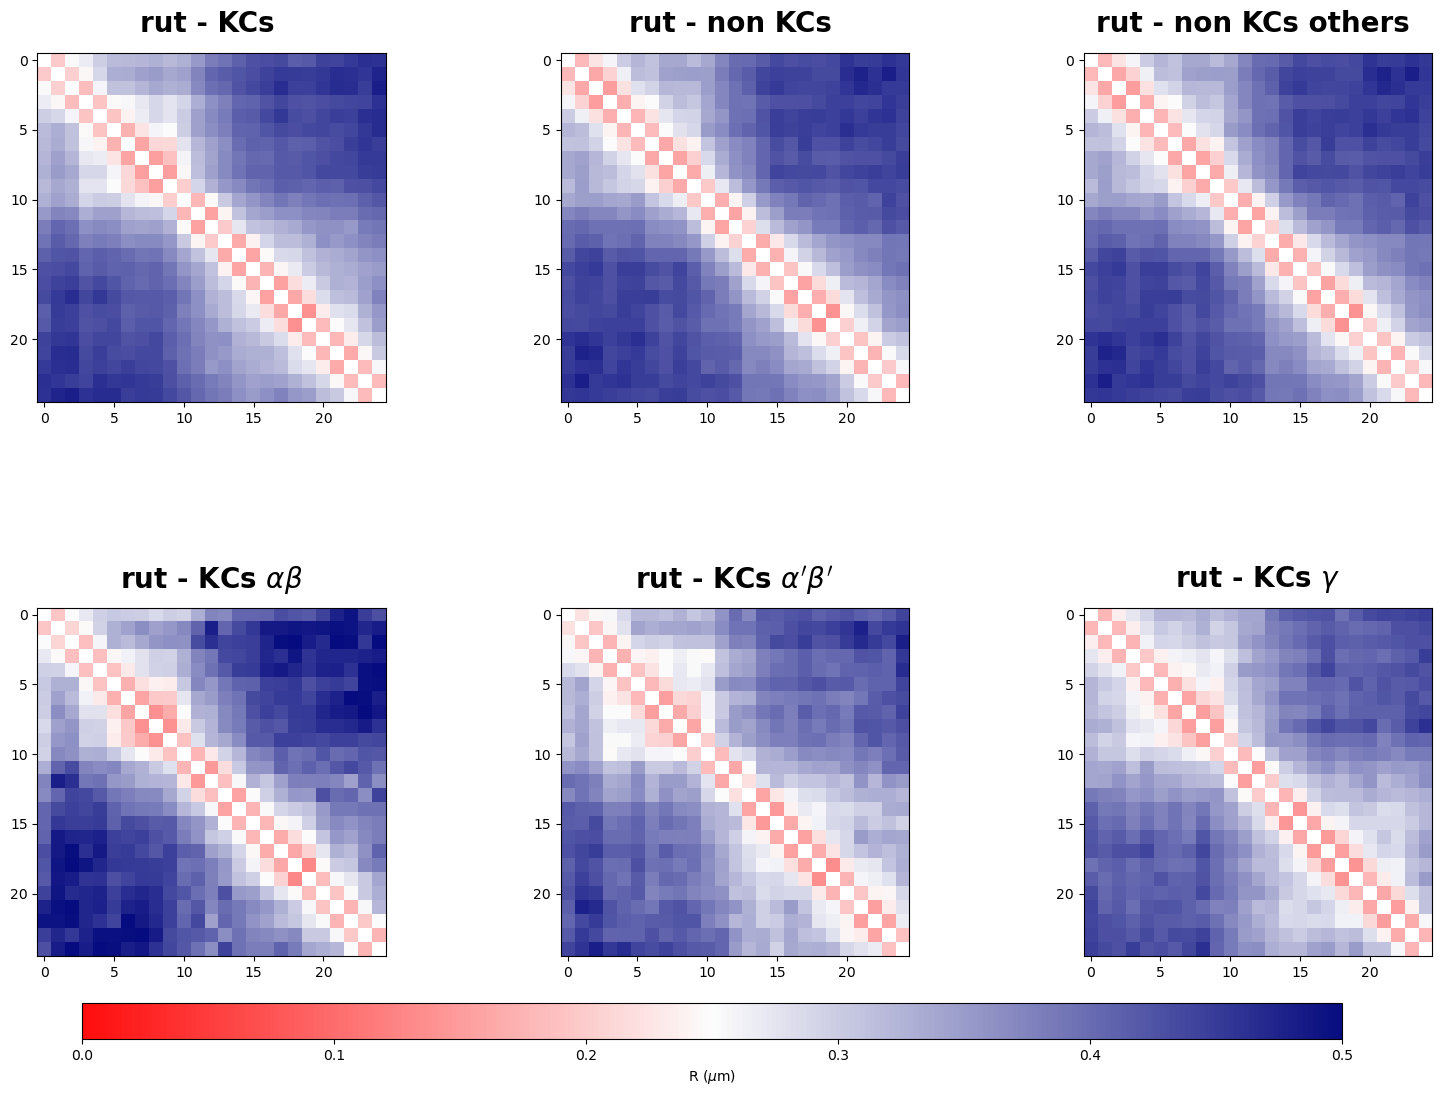

In [18]:
# Plot rut distances matrix
plot_distances_matrix(rut_to_process, cell_lines_to_process, title='rut')

## 3.3 Summary diagrams of $R_L$, $R_{NL}$ and $f_L$ for all the cell lines

In [19]:
# plot_matrices(rut_RESULTS)

In [20]:
# Process the cell line data with fixed R1 and R2 from non-Kenyon cells and calculate f_alpha for Kenyon cells.
def process_cell_line_with_ref(data_dict,ref, cell_line, bins):
    """
    Process the cell line data with fixed R1 and R2 from ref cells and calculate f_alpha for Kenyon cells.
    Parameters:
        - data_dict (dict): Dictionary containing the data for different cell lines.
        - cell_line (str): Name of the cell line to process.
        - bins (array): Array containing the bin edges for histogram.
    Returns:
      - None
    """
    # Access pre-calculated matrices
    distance_mats = data_dict[cell_line]['distmat']
    
    Re1_matrix = data_dict[ref]['Re1_matrix']
    Re2_matrix = data_dict[ref]['Re2_matrix']
    fr_matrix = data_dict[ref]['fr_matrix']
    
    DRe1_matrix = data_dict[ref]['DRe1_matrix']
    DRe2_matrix = data_dict[ref]['DRe2_matrix']
    Dfr_matrix = data_dict[ref]['Dfr_matrix']

    ni = np.linspace(0, Re1_matrix.shape[0] - 1, Re1_matrix.shape[0], dtype=int)
    nj = np.linspace(0, Re1_matrix.shape[1] - 1, Re1_matrix.shape[1], dtype=int)
    fr_matrix_fixed = np.zeros((len(ni), len(nj)))
    Re1_matrix_fixed = np.zeros((len(ni), len(nj)))    
    Re2_matrix_fixed = np.zeros((len(ni), len(nj)))
    
    DRe1_matrix_fixed = np.zeros((len(ni), len(nj)))
    DRe2_matrix_fixed = np.zeros((len(ni), len(nj)))
    Dfr_matrix_fixed = np.zeros((len(ni), len(nj)))

    epsilon = 1e-5  # small value to ensure bounds are not equal

    for i in range(len(ni)):
        for j in range(len(nj)):
            # Fix Re1 and Re2 using Non-Kenyon data
            R1_ref = Re1_matrix[i, j]
            R2_ref = Re2_matrix[i, j]
            DR1_ref = DRe1_matrix[i, j]
            DR2_ref = DRe2_matrix[i, j]
            
            R1_ref_min = R1_ref - DR1_ref - epsilon
            R1_ref_max = R1_ref + DR1_ref + epsilon
            R2_ref_min = R2_ref - DR2_ref - epsilon
            R2_ref_max = R2_ref + DR2_ref + epsilon
            
            # print("R1_ref_min:", R1_ref_min)
            # print("R1_ref_max:", R1_ref_max)
            # print("R2_ref_min:", R2_ref_min)
            # print("R2_ref_max:", R2_ref_max)
            
            if R1_ref_min == R1_ref_max:
                print(f"Error processing {cell_line}: R1_ref_min > R1_ref_max")

                
            if R2_ref_min > R2_ref_max:
                print(f"Error processing {cell_line}: R2_ref_min > R2_ref_max")


            # Skip if R1 or R2 is zero
            if R1_ref_min == 0 or R2_ref_min == 0:
                continue
            nx = ni[i]
            ny = nj[j]
            datah = np.array(distance_mats[nx, ny, :])
            nn, bins = np.histogram(datah, bins)

            b0 = bins[0]
            bins2 = []
            deltab = []

            for bb in bins[1:]:
                bins2.append((bb + b0) / 2)
                deltab.append(bb - b0)
                b0 = bb
            if np.sum(nn) == 0:
                continue
            else:
                try:
                    # Perform curve fitting with fixed R1 and R2
                    popt, pcov = curve_fit(TWO_GAUSSIAN_DISTR_FIXED_R,bins2, (nn / deltab) / np.sum(nn), bounds=(( R1_ref_min, R2_ref_min, 0.0), ( R1_ref_max, R2_ref_max, 1.0)))
                    # Calculate the uncertainties
                    perr = np.sqrt(np.diag(pcov))
                except RuntimeError as e:
                    print(f"Error processing {cell_line}: {e}")
                    # Continue to the next iteration
                    continue


                # Extract f_alpha from the fitted parameters
                if popt[0] < popt[1]:
                    Re1 = popt[0]
                    Re2 = popt[1]
                    fr = popt[2]
                    
                    DRe1 = perr[0]
                    DRe2 = perr[1]
                    Dfr = perr[2]
                else:
                    Re2 = popt[0]
                    Re1 = popt[1]
                    fr = 1 - popt[2]
                    
                    DRe2 = perr[0]
                    DRe1 = perr[1]
                    Dfr = perr[2]

                Re1_matrix_fixed[i, j] = np.round(Re1, 2)
                Re2_matrix_fixed[i, j] = np.round(Re2, 2)
                fr_matrix_fixed[i, j] = np.round(fr, 2)
                
                DRe1_matrix_fixed[i, j] = np.round(DRe1, 4)
                DRe2_matrix_fixed[i, j] = np.round(DRe2, 4)
                Dfr_matrix_fixed[i, j] = np.round(Dfr, 4)
                
                

                # Store f_alpha in the fr_matrix for Kenyon cells

    print(np.round(np.sum(np.abs(fr_matrix_fixed-fr_matrix))/np.sum(fr_matrix)*100,2),'%')
  
    # Update the data dictionary with the calculated fr_matrix
    data_dict[cell_line]['Re1_matrix_fixed'] = Re1_matrix_fixed
    data_dict[cell_line]['Re2_matrix_fixed'] = Re2_matrix_fixed
    data_dict[cell_line]['fr_matrix_fixed'] = fr_matrix_fixed
    
    data_dict[cell_line]['DRe1_matrix_fixed'] = DRe1_matrix_fixed
    data_dict[cell_line]['DRe2_matrix_fixed'] = DRe2_matrix_fixed
    data_dict[cell_line]['Dfr_matrix_fixed'] = Dfr_matrix_fixed

    print(f"{cell_line}: done")


    

#

In [21]:
data_dict_to_process = rut_RESULTS  
cell_lines_to_process = None
for cell_line in data_dict_to_process:
    process_cell_line(data_dict_to_process, cell_line, bins)

/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/1009309798.py:129: RuntimeWarning: Mean of empty slice
  data_dict[cell_line]['Rt_matrix'] = np.round(np.sqrt(np.nanmean(distance_mats**2, axis=2)), 2)


KCs : done
(25, 25, 30746)
KCs $\alpha \beta$ : done
(25, 25, 7573)
KCs $\alpha' \beta'$ : done
(25, 25, 5775)
KCs $\gamma$ : done
(25, 25, 7081)
non KCs others : done
(25, 25, 34887)
$non KCs \alpha \beta$ : done
(25, 25, 70417)
non KCs $\alpha' \beta'$ : done
(25, 25, 112237)
non KCs $\gamma$ : done
(25, 25, 115829)
non KCs : done
(25, 25, 34887)
All cells : done
(25, 25, 86062)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def calculate_pairwise_genomic_distances(bc_position):
    n = len(bc_position)
    pairwise_distances = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            pairwise_distances[i, j] = abs(bc_position[i] - bc_position[j])
    return pairwise_distances

def power_function(x, a, b):
    epsilon = 1e-10
    return a * ((x + epsilon)**b)

def plot_loglog_mean_distances(RESULTS, cell_lines):
    fig, ax = plt.subplots(figsize=(8, 5))

    for cell_line in cell_lines:
        data = RESULTS[cell_line]
        bc_position = np.array(data['bc_position'])
        distmat = np.array(data['distmat'])
        color = data['color']

        genomic_distances = calculate_pairwise_genomic_distances(bc_position)
        mean_spatial_distances = np.nanmean(distmat, axis=2)

        unique_genomic_distances = np.unique(genomic_distances)
        mean_distances = []

        for dist in unique_genomic_distances:
            mask = genomic_distances == dist
            mean_distances.append(np.nanmean(mean_spatial_distances[mask]))

        mean_distances = np.array(mean_distances)

        valid_mask = np.isfinite(mean_distances)
        unique_genomic_distances = unique_genomic_distances[valid_mask]
        mean_distances = mean_distances[valid_mask]

        pt, pcov = curve_fit(power_function, unique_genomic_distances, mean_distances)

        ax.scatter(unique_genomic_distances, mean_distances, color=color, facecolors='none', edgecolors=color)
        ax.loglog(unique_genomic_distances, power_function(unique_genomic_distances, *pt), c='r')

        x_text = unique_genomic_distances[-1] 
        y_text = power_function(unique_genomic_distances[-1], *pt) - 0.25
        ax.text(x_text, y_text, r'$b=$' + f'{np.round(pt[1], 2)}', fontsize=18, ha='right', color='r')

    ax.set_xlabel('Genomic distance (bp)', fontsize=20)
    ax.set_ylabel('Mean spatial distance (µm)', fontsize=20)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='both', labelsize=18)
    plt.yticks([ 0.2, 0.3, 0.4])

    plt.tight_layout()
    plt.subplots_adjust(right=0.75)
    plt.savefig('loglog_mean_distances.svg', dpi=300)
    plt.show()



/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/2825126249.py:27: RuntimeWarning: Mean of empty slice
  mean_spatial_distances = np.nanmean(distmat, axis=2)
/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/2825126249.py:34: RuntimeWarning: Mean of empty slice
  mean_distances.append(np.nanmean(mean_spatial_distances[mask]))


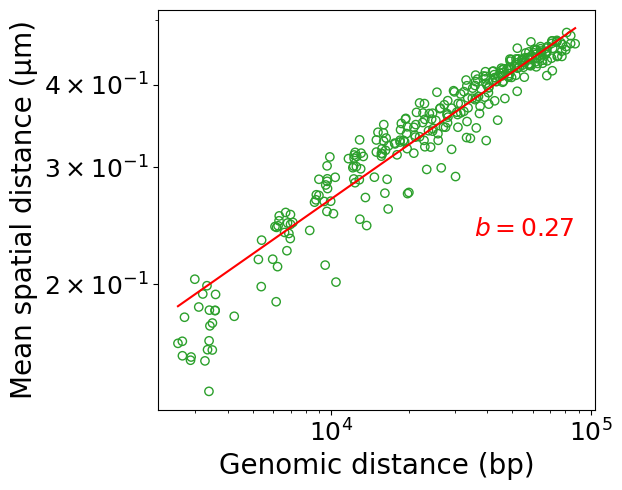

In [26]:
# Example usage:
plot_loglog_mean_distances(rut_RESULTS, ['KCs'])

/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/2772558107.py:7: RuntimeWarning: invalid value encountered in scalar divide
  contact_frequency[i, j] = np.sum(valid_distances < threshold) / len(valid_distances)
/var/folders/fc/n6nc_z0j1txdb3kr5jl8lqw00000gp/T/ipykernel_69910/2772558107.py:27: RuntimeWarning: Mean of empty slice
  mean_contact_frequencies.append(np.nanmean(contact_frequency[mask]))


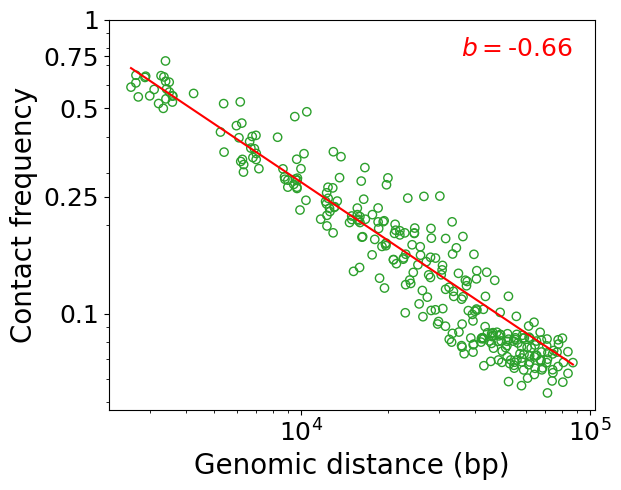

In [27]:
def calculate_contact_frequency(distmat, threshold=0.15):
    n = distmat.shape[0]
    contact_frequency = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            valid_distances = distmat[i, j][~np.isnan(distmat[i, j])]
            contact_frequency[i, j] = np.sum(valid_distances < threshold) / len(valid_distances)
    return contact_frequency

def plot_loglog_contact_frequency(RESULTS, cell_lines):
    fig, ax = plt.subplots(figsize=(8, 5))

    for cell_line in cell_lines:
        data = RESULTS[cell_line]
        bc_position = np.array(data['bc_position'])
        distmat = np.array(data['distmat'])
        color = data['color']

        genomic_distances = calculate_pairwise_genomic_distances(bc_position)
        contact_frequency = calculate_contact_frequency(distmat)

        unique_genomic_distances = np.unique(genomic_distances)
        mean_contact_frequencies = []

        for dist in unique_genomic_distances:
            mask = genomic_distances == dist
            mean_contact_frequencies.append(np.nanmean(contact_frequency[mask]))

        mean_contact_frequencies = np.array(mean_contact_frequencies)

        valid_mask = np.isfinite(mean_contact_frequencies)
        unique_genomic_distances = unique_genomic_distances[valid_mask]
        mean_contact_frequencies = mean_contact_frequencies[valid_mask]

        ax.scatter(unique_genomic_distances, mean_contact_frequencies, color=color, facecolors='none', edgecolors=color)
        # ax.loglog(unique_genomic_distances, mean_contact_frequencies, c=color)
        
        pt, pcov = curve_fit(power_function, unique_genomic_distances, mean_contact_frequencies)

        ax.loglog(unique_genomic_distances, power_function(unique_genomic_distances, *pt), c='r')

        x_text = unique_genomic_distances[-1]
        y_text = 0.75
        ax.text(x_text, y_text, r'$b=$' + f'{np.round(pt[1], 2)}', fontsize=18, ha='right', color='r')

    ax.set_xlabel('Genomic distance (bp)', fontsize=20)
    ax.set_ylabel('Contact frequency', fontsize=20)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='both', labelsize=18)

    plt.yticks([ 0.1, 0.25, 0.5, 0.75,1],['0.1','0.25', '0.5', '0.75','1'])

    plt.tight_layout()
    plt.subplots_adjust(right=0.75)
    plt.savefig('loglog_contact_frequency.svg', dpi=300)
    plt.show()

# Example usage:
plot_loglog_contact_frequency(rut_RESULTS, ['KCs'])

# **3. Distances distributions' fits**


In [28]:
# Here we show some exemples of pairwise distance distributions of tag 20 with a selection of other tags
# for different cell lines
# Experimental data is shown as black circles, the gaussian model fit is in green, the two-phases model fit 
# is shown  in black (alpha phase is in red and beta in blue)
# The dashed lines show the fits with fixed radii from non-Kenyon cells
def plot_distance_distributions(data_dict, tag, dtag, bins, cell_lines):
    if cell_lines is None:
        cell_lines = list(data_dict.keys())
    else:
        cell_lines = [cell_line for cell_line in cell_lines if cell_line in data_dict]

    for cell_line in cell_lines:
        # Get the distance matrix for the current cell line
        dm = data_dict[cell_line]['distmat']
        bc_name = data_dict[cell_line]['bc_names']
        
        # Use the pre-calculated matrices to fit the distributions
        # Re1_matrix_fixed = data_dict[cell_line]['Re1_matrix_fixed']
        # Re2_matrix_fixed = data_dict[cell_line]['Re2_matrix_fixed']
        # fr_matrix_fixed = data_dict[cell_line]['fr_matrix_fixed']


        Re1_matrix = data_dict[cell_line]['Re1_matrix']
        Re2_matrix = data_dict[cell_line]['Re2_matrix']
        fr_matrix = data_dict[cell_line]['fr_matrix']
        
        DRe1_matrix = data_dict[cell_line]['DRe1_matrix']
        DRe2_matrix = data_dict[cell_line]['DRe2_matrix']
        Dfr_matrix = data_dict[cell_line]['Dfr_matrix']

        uniqueR_matrix = data_dict[cell_line]['Unique_R']
        DRe_unique_matrix = data_dict[cell_line]['DUnique_R']


        # Create a new figure for plotting
        fig = plt.figure(figsize=(12, 10))
        fig.suptitle(cell_line, fontsize=20, fontweight='bold')

        # Define subplot positions for plotting
        nplots = [231, 232, 233, 234, 235, 236]

        # Iterate over different tag differences (dtag)
        for i, dt in enumerate(dtag):
            # Extract distances based on the tag and tag difference

            # Create a histogram and calculate bin centers
            rr = dm[tag, tag + dt, :]
            hist, bins = np.histogram(rr, bins=bins, density=True)
            bc = 0.5 * (bins[1:] + bins[:-1])
            # Create a range for plotting
            rr = np.linspace(0, 1.0, 200)

            # Add a subplot to the figure
            ax = fig.add_subplot(nplots[i])

            # Plot the Gaussian distribution with parameters and labels
            # plt.plot(rr, GAUSSIAN_DISTR(rr, uniqueR_matrix[tag,tag+dt]), c='tab:green', lw=2, label=r'$R=$' + str(np.round(uniqueR_matrix[tag,tag+dt], 2)) )
            # plt.plot(rr, fr_matrix[tag,tag+dt] * GAUSSIAN_DISTR(rr, Re1_matrix[tag,tag+dt]), color='tab:red', lw=1)
            # plt.plot(rr, (1 - fr_matrix[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re2_matrix[tag,tag+dt]), color='tab:blue', lw=1)
            
            # Calculate the lower and upper bounds for the error
            lower_bound_red = (fr_matrix[tag,tag+dt]- Dfr_matrix[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re1_matrix[tag,tag+dt]) 
            upper_bound_red = (fr_matrix[tag,tag+dt]+ Dfr_matrix[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re1_matrix[tag,tag+dt])
            
            lower_bound_blue = (1 - fr_matrix[tag,tag+dt]- Dfr_matrix[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re2_matrix[tag,tag+dt])
            upper_bound_blue = (1 - fr_matrix[tag,tag+dt]+ Dfr_matrix[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re2_matrix[tag,tag+dt])


            # Plot the data with error bars
            plt.plot(rr, fr_matrix[tag,tag+dt] * GAUSSIAN_DISTR(rr, Re1_matrix[tag,tag+dt]), color='tab:red', lw=1)
            # plt.fill_between(rr, lower_bound_red, upper_bound_red, color='tab:red', alpha=0.2)
            
            plt.plot(rr, (1 - fr_matrix[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re2_matrix[tag,tag+dt]), color='tab:blue', lw=1)
            # plt.fill_between(rr, lower_bound_blue, upper_bound_blue, color='tab:blue', alpha=0.2)

            # # Fixed plots
            # plt.plot(rr, fr_matrix_fixed[tag,tag+dt] * GAUSSIAN_DISTR(rr, Re1_matrix_fixed[tag,tag+dt]),'--', color='tab:red', lw=1)
            # # plt.fill_between(rr, (1 - param2[2]) * GAUSSIAN_DISTR(rr, param2[1]), color='tab:blue', alpha=0.2)
            # plt.plot(rr, (1 - fr_matrix_fixed[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re2_matrix_fixed[tag,tag+dt]), '--',color='tab:blue', lw=1)
            # 
            # plt.fill_between(rr, fr_matrix[tag,tag+dt] * GAUSSIAN_DISTR(rr, Re1_matrix[tag,tag+dt]),fr_matrix_fixed[tag,tag+dt] * GAUSSIAN_DISTR(rr, Re1_matrix_fixed[tag,tag+dt]), color='tab:red', alpha=0.2)
            # plt.fill_between(rr, (1 - fr_matrix[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re2_matrix[tag,tag+dt]),(1 - fr_matrix_fixed[tag,tag+dt]) * GAUSSIAN_DISTR(rr, Re2_matrix_fixed[tag,tag+dt]), color='tab:blue', alpha=0.2)

            # Add labels for the weighted Gaussian distribution
            label = r'$R_P$=' + str(np.round(Re1_matrix[tag,tag+dt], 2)) + '\n' + r' $R_{NP}$=' + str(np.round(Re2_matrix[tag,tag+dt], 2)) + '\n' + r'$f_P=$' + str(np.round(fr_matrix[tag,tag+dt], 2))

            # Retrieve R-squared for the Gaussian model fit and the two-phases model fit
            r2_gauss = data_dict[cell_line]['R_squared_gauss_matrix'][tag, tag+dt]
            r2_two_phases = data_dict[cell_line]['R_squared_matrix'][tag, tag+dt]
            
            # label = r'$R^2_{{Double}}= {r2_two_phases:.2f}$'.format(r2_two_phases=r2_two_phases)
            # label_green = r'$R^2_{{Gauss}}= {r2_gauss:.2f}$'.format(r2_gauss=r2_gauss)
            # label_fixed = r'$R_L$=' + str(np.round(Re1_matrix_fixed[tag,tag+dt], 2)) + '\n' + r' $R_{NL}$=' + str(np.round(Re2_matrix_fixed[tag,tag+dt], 2)) + '\n' + r'$f_L=$' + str(np.round(fr_matrix_fixed[tag,tag+dt], 2))
            # 
            
            
            plt.plot(rr, TWO_GAUSSIAN_DISTR(rr, Re1_matrix[tag,tag+dt],Re2_matrix[tag,tag+dt],fr_matrix[tag,tag+dt]), c='tab:purple', lw=2, label=label)
            # plt.plot(rr, GAUSSIAN_DISTR(rr, uniqueR_matrix[tag,tag+dt]), c='tab:green', lw=2,label = r'$R_{gaussian}$=' + str(np.round(uniqueR_matrix[tag,tag+dt], 2)))
            
            plt.plot(rr, GAUSSIAN_DISTR(rr, uniqueR_matrix[tag,tag+dt]), c='tab:green', lw=2,label = r'$R_g$=' + str(np.round(uniqueR_matrix[tag,tag+dt], 2)))
            
            # plt.plot(rr, TWO_GAUSSIAN_DISTR(rr, Re1_matrix_fixed[tag,tag+dt],Re2_matrix_fixed[tag,tag+dt],fr_matrix_fixed[tag,tag+dt]),'--', c='black', lw=2, label=label_fixed)
            # 
            # plt.fill_between(rr, TWO_GAUSSIAN_DISTR(rr, Re1_matrix[tag,tag+dt],Re2_matrix[tag,tag+dt],fr_matrix[tag,tag+dt]),TWO_GAUSSIAN_DISTR(rr, Re1_matrix_fixed[tag,tag+dt],Re2_matrix_fixed[tag,tag+dt],fr_matrix_fixed[tag,tag+dt]), color='black', alpha=0.2)
            # Plot the data points
            plt.plot(bc, hist, 'o', ms=8, mew=3, mec='black', c='black')

            # Customize plot limits and legend position
            plt.xlim([0, 1.0])
            if nplots[i] in [231, 232]:
                plt.ylim([0, 7.2])
            if nplots[i] in [233, 234]:
                plt.ylim([0, 7.2])
            if nplots[i] in [235, 236]:
                plt.ylim([0, 7.2])
            plt.legend(loc='upper right', fontsize=16)




            # Customize plot appearance
            # if nplots[i] in [231]:
            #     plt.text(0.1, 0.3, r'$\mathbf{L}$', transform=ax.transAxes, fontsize=25, color='tab:red')
            #     plt.text(0.25, 0.05, r'$\mathbf{\beta}$', transform=ax.transAxes, fontsize=25, color='tab:blue')
            plt.tick_params(labelsize=18)
            if nplots[i] in [234, 235,236]:
                plt.xlabel(r'$r$ (µm)', size=18)
                
            if nplots[i] in [231, 234]:
                plt.ylabel(r'$P(r) (µm^{-1}$)', size=18)
            if nplots[i] in [231]:
                plt.xticks([0, 0.25, 0.5, 0.75, 1.0])
                plt.yticks([0, 2, 4, 6])
            if nplots[i] in [232, 233]:
                plt.xticks([0, 0.25, 0.5, 0.75, 1.0],)
                plt.yticks([0, 2, 4, 6],[])
            # if nplots[i] in [232, 233]:
            #     plt.yticks([0, 2, 4, 6],[])
            # if nplots[i] > 230:
            #     plt.xticks([0, 0.25, 0.5, 0.75, 1.0])
            #     plt.yticks([0, 2, 4, 6])
            plt.title(f'{bc_name[tag]}-{bc_name[tag+dt]}', fontsize=16)

        # Adjust the layout for better presentation
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig('some_distributions_awayfromTAD_KC.svg', dpi=300)
        plt.show()
        


## 3.2 rut Tissue cell lines

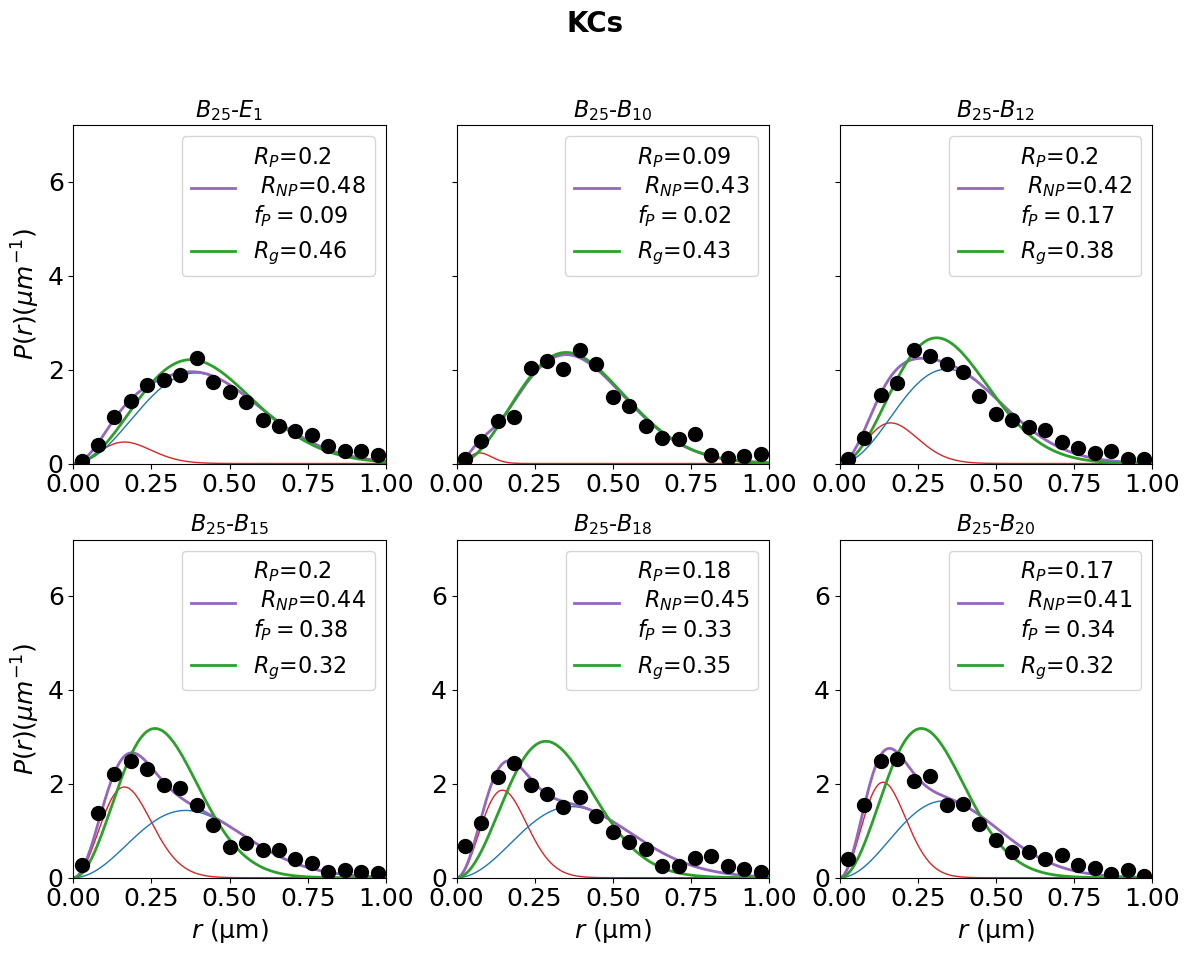

In [29]:
#rut_prom_bc = rut_bc_type.index(r"$P_\text{rut}$")
#
rut_prom_bc = 24
cell_lines_to_process=None
# plot_distance_distributions(rut_to_process, rut_prom_bc, [ -9,  -4, +10], bins,  cell_lines_to_process)

plot_distance_distributions(rut_to_process, rut_prom_bc, [-20, -15,-13,-10, -7,-5], bins,  ['KCs'])
#plot_distance_distributions(rut_to_process, rut_prom_bc, [3, 4,5,6 , 7, 10], bins,  ['KCs'])


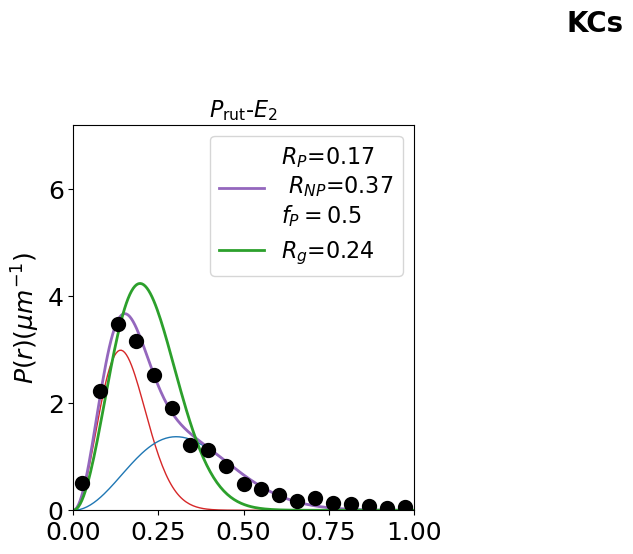

In [30]:
rut_prom_bc = rut_bc_type.index(r"$P_\text{rut}$")
cell_lines_to_process=['KCs']
plot_distance_distributions(rut_to_process, rut_prom_bc, [ -4], bins,  cell_lines_to_process)

## 3.4 Plot of ($f_L, R_L, R_{NL}$) vs the genomic position (kbp)

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_goodness_fit(RESULTS, cell_lines, ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())

    # Determine the type of tissues (sNPF or rut) based on the dictionary name
    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)
    else:
        raise ValueError('Invalid dictionary')

    columns = 2
    lines = max(1, (len(cell_lines) + columns - 1) // columns)  # Ensure at least one row
    fig, axs = plt.subplots(lines, columns, figsize=(columns*7, lines*6), sharex='col')

    # Ensure axs is always a 2D array
    if lines == 1:
        axs = np.expand_dims(axs, axis=0)
    if columns == 1:
        axs = np.expand_dims(axs, axis=1)

    for cl, cell_line in enumerate(cell_lines):
        r2_two_phases_matrix = RESULTS[cell_line]['R_squared_matrix']
        r2_gauss_matrix = RESULTS[cell_line]['R_squared_gauss_matrix']
        r2_two_phases = r2_two_phases_matrix[ref_bc, :]
        r2_gauss = r2_gauss_matrix[ref_bc, :]

        bc_position = RESULTS[cell_line]['bc_position']
        bc_position = np.array([(i - bc_position[ref_bc])/1000 for i in bc_position])

        ax = axs[cl // columns, cl % columns]

        ax.plot(bc_position, r2_two_phases, 'o-',label='Two-states', color='tab:purple')
        ax.plot(bc_position, r2_gauss, 'o-', label='One-state', color='tab:green')
        # ax.set_title(RESULTS[cell_line]['name'], fontsize=18)
        ax.set_ylim(0, 1)
        ax.set_xticks([-40, -20, 0, 20, 40])
        ax.set_ylabel(r"$\mathcal{R}^{2}$", fontsize=18, rotation=0, rotation_mode='anchor', labelpad=10)
        ax.set_xlabel('Genomic distance (kb)', fontsize=18)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
        ax.legend(fontsize=18, loc='center right')
        ax.tick_params(axis='both', which='both', labelsize=18)

    plt.tight_layout(pad=2.0)
    plt.savefig('KC_goodness_fit_S2-E.svg', dpi=300)
    plt.show()

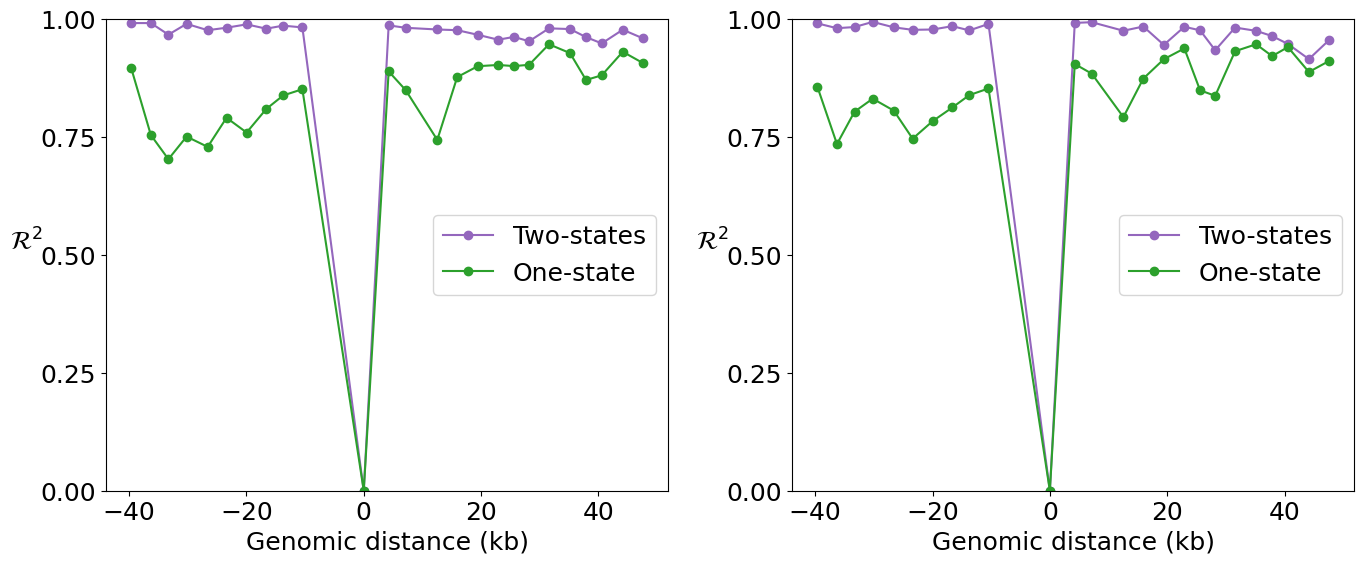

In [32]:

rut_prom_ref = r"$P_\text{rut}$"
plot_goodness_fit(rut_RESULTS,  ['KCs','non KCs'], rut_prom_ref)

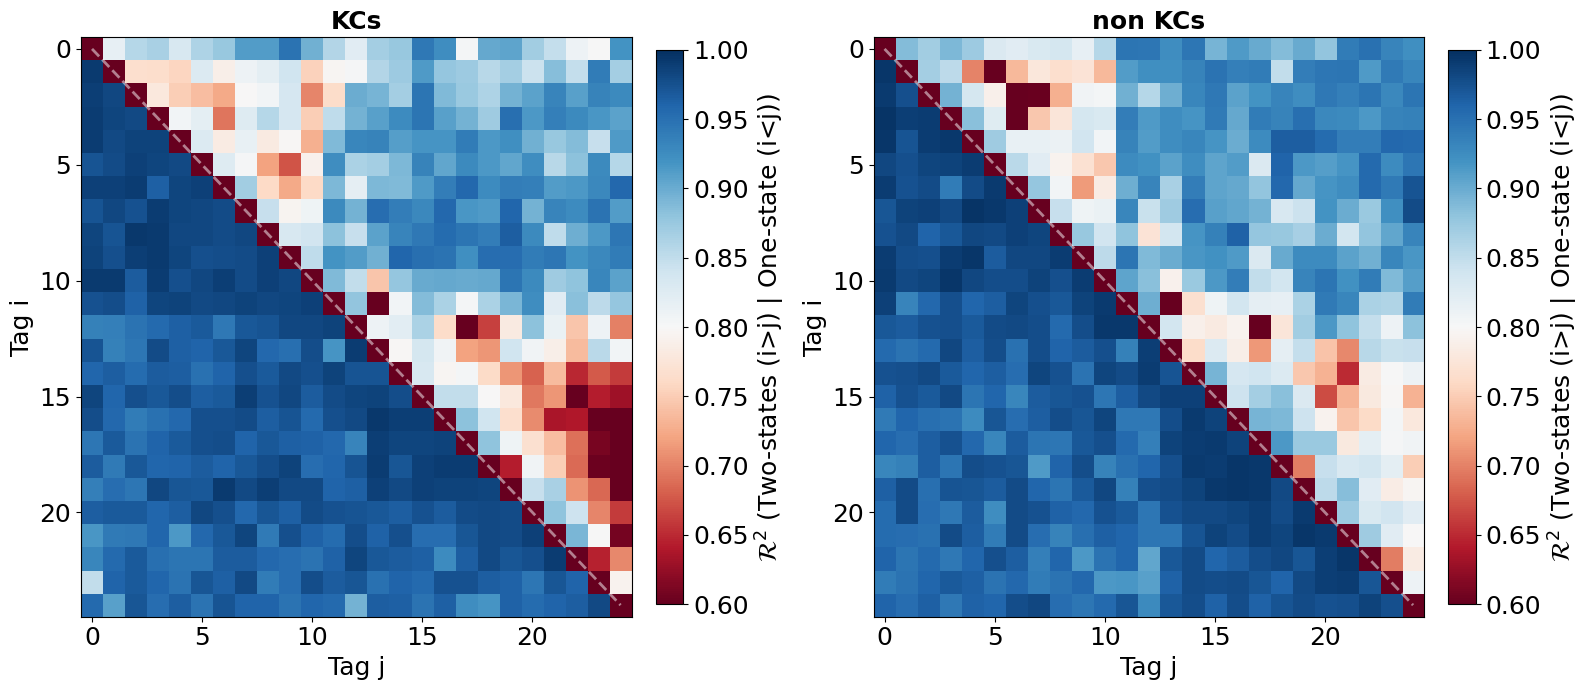

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_goodness_fit_matrix(RESULTS, cell_lines):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())

    # Determine the type of tissues (sNPF or rut) based on the dictionary name
    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
    else:
        raise ValueError('Invalid dictionary')

    # Create subplots for each cell line
    fig, axs = plt.subplots(1, len(cell_lines), figsize=(len(cell_lines)*8, 7), squeeze=False)
    axs = axs[0]  # Flatten to 1D array

    for cl, cell_line in enumerate(cell_lines):
        r2_two_phases_matrix = RESULTS[cell_line]['R_squared_matrix']
        r2_gauss_matrix = RESULTS[cell_line]['R_squared_gauss_matrix']

        # Créer une matrice combinée exploitant la symétrie
        # Two phases quand i > j, Gaussian quand i < j
        combined_matrix = np.copy(r2_two_phases_matrix)
        n = combined_matrix.shape[0]

        for i in range(n):
            for j in range(n):
                if i < j:
                    combined_matrix[i, j] = r2_gauss_matrix[i, j]

        ax = axs[cl]

        # Créer la heatmap
        im = ax.imshow(combined_matrix, cmap='RdBu', aspect='auto', vmin=0.6, vmax=1)

        # Labels
        ax.set_xlabel('Tag j', fontsize=18)
        ax.set_ylabel('Tag i', fontsize=18)
        ax.set_title(RESULTS[cell_line]['name'], fontsize=18, fontweight='bold')

        # Ajouter une ligne diagonale pour bien voir la séparation
        ax.plot([0, n-1], [0, n-1], 'w--', linewidth=2, alpha=0.5)

        # Colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(r"$\mathcal{R}^{2}$ (Two-states (i>j) | One-state (i<j))", fontsize=18)
        cbar.ax.tick_params(labelsize=18)
        ax.tick_params(axis='both', which='both', labelsize=18)

    plt.tight_layout()
    plt.savefig('KC_goodness_fit_matrix.svg', dpi=300, bbox_inches='tight')
    plt.show()

# Appel simplifié
plot_goodness_fit_matrix(rut_RESULTS, ['KCs','non KCs'])


In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_alpha_fraction_with_r2_inset(RESULTS, cell_lines, ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())

    # Determine the type of tissues (sNPF or rut) based on the dictionary name
    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)
    else:
        raise ValueError('Invalid dictionary')

    columns = 3
    lines = len(cell_lines) // columns
    fig, axs = plt.subplots(lines, columns, figsize=(columns*7, lines*6), sharex='col', sharey='row')
    # plt.suptitle(f'{tissues_type}', fontsize=20, fontweight='bold', y=1.05)

    for cl, cell_line in enumerate(cell_lines):
        name = RESULTS[cell_line]['name']
        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']
        bc_position = RESULTS[cell_line]['bc_position']
        genomic_dist = RESULTS[cell_line]['genomic_dist']

        DRe1_matrix = RESULTS[cell_line]['DRe1_matrix']
        DRe2_matrix = RESULTS[cell_line]['DRe2_matrix']
        Dfr_matrix = RESULTS[cell_line]['Dfr_matrix']

        R_matrix = RESULTS[cell_line]['Unique_R']
        DR_matrix = RESULTS[cell_line]['DUnique_R']

        color = RESULTS[cell_line]['color']
        bc_color = RESULTS[cell_line]['bc_color']

        fa = fr_matrix[ref_bc, :]
        Re1 = Re1_matrix[ref_bc, :]
        Re2 = Re2_matrix[ref_bc, :]

        Dfa = Dfr_matrix[ref_bc, :]
        DRe1 = DRe1_matrix[ref_bc, :]
        DRe2 = DRe2_matrix[ref_bc, :]

        R_gauss = R_matrix[ref_bc, :]
        DR_gauss = DR_matrix[ref_bc, :]

        other_bc = [i for i in range(Re1_matrix.shape[0]) if i != ref_bc]
        fa_other = np.mean(fr_matrix[other_bc, :], axis=0)

        r2_two_phases_matrix = RESULTS[cell_line]['R_squared_matrix']
        r2_gauss_matrix = RESULTS[cell_line]['R_squared_gauss_matrix']
        r2_two_phases = r2_two_phases_matrix[ref_bc, :]
        r2_gauss = r2_gauss_matrix[ref_bc, :]

        upper_Re1 = Re1 + DRe1
        lower_Re1 = Re1 - DRe1
        upper_Re2 = Re2 + DRe2
        lower_Re2 = Re2 - DRe2

        upper_R = R_gauss + DR_gauss
        lower_R = R_gauss - DR_gauss

        condition = ((lower_Re1 >= lower_Re2) & (upper_Re1 <= upper_Re2)) | ((lower_Re2 >= lower_Re1) & (upper_Re2 <= upper_Re1)) | (((lower_R >= lower_Re1) & (upper_R <= upper_Re1 )) | ((R_gauss >= lower_Re2) & (R_gauss <= upper_Re2))) | (r2_two_phases - 0.07 < r2_gauss ) | (Dfa > 1/5)
        print(condition)
        condition = np.full(25, False)

        bc_position = np.array([(i - bc_position[ref_bc])/1000 for i in bc_position])

        # Mask the data points where the condition is met
        mask = ~condition

        ax = axs[cl // columns, cl % columns]

        # Plot segments where mask is True
        for i in range(len(mask)):
            if mask[i]:
                start = i
                while i < len(mask) and mask[i]:
                    i += 1
                end = i
                ax.plot(bc_position[start:end], fa[start:end], linewidth=2, color=color, label=name if start == 0 else "")
                ax.errorbar(bc_position[start:end], fa[start:end], yerr=Dfa[start:end], fmt='o', color=color, ecolor=color, capsize=4, capthick=2)

        # ax.set_title(name, fontsize=18)
        ax.bar(bc_position, 0.1, width=2, color=bc_color, linewidth=3.5, alpha=1, bottom=0.9)
        ax.legend(fontsize=18, loc='right')
        ax.set_xscale('linear')
        ax.tick_params(axis='both', which='both', labelsize=18)
        ax.set_ylim(0, 1)
        ax.set_xticks([-40, -20, 0, 20, 40])
        # ax.set_xticklabels([])  # Hide tick labels for ax
        # if cl == 0 or cl == 3:
        ax.set_ylabel(r"$f_B$", fontsize=18, rotation=-0, rotation_mode='anchor', labelpad=10)
        ax.set_yticks([0.25, 0.5, 0.75])
        # ax.set_yticklabels([r'$0.25$', r'$0.5$',r'$0.75$'])

    plt.tight_layout(pad=2.0)  # Increased pad to 2.0
    plt.show()

[False False False False False False False False False False  True False
 False False False  True  True  True  True  True  True False  True  True
  True]
[False False False False False False False False False False  True False
 False False False  True  True False False  True  True  True  True  True
  True]
[False False False False False False False False False False  True False
 False False False  True  True False False  True  True  True  True  True
  True]
[False False False False False False False False False False  True  True
 False False False False False False  True  True False False  True False
  True]
[False False False False False False False False False False  True False
 False False False False  True  True  True  True  True  True  True  True
  True]
[False False False False False False False False False False  True False
 False False False False False False False False False False False False
 False]


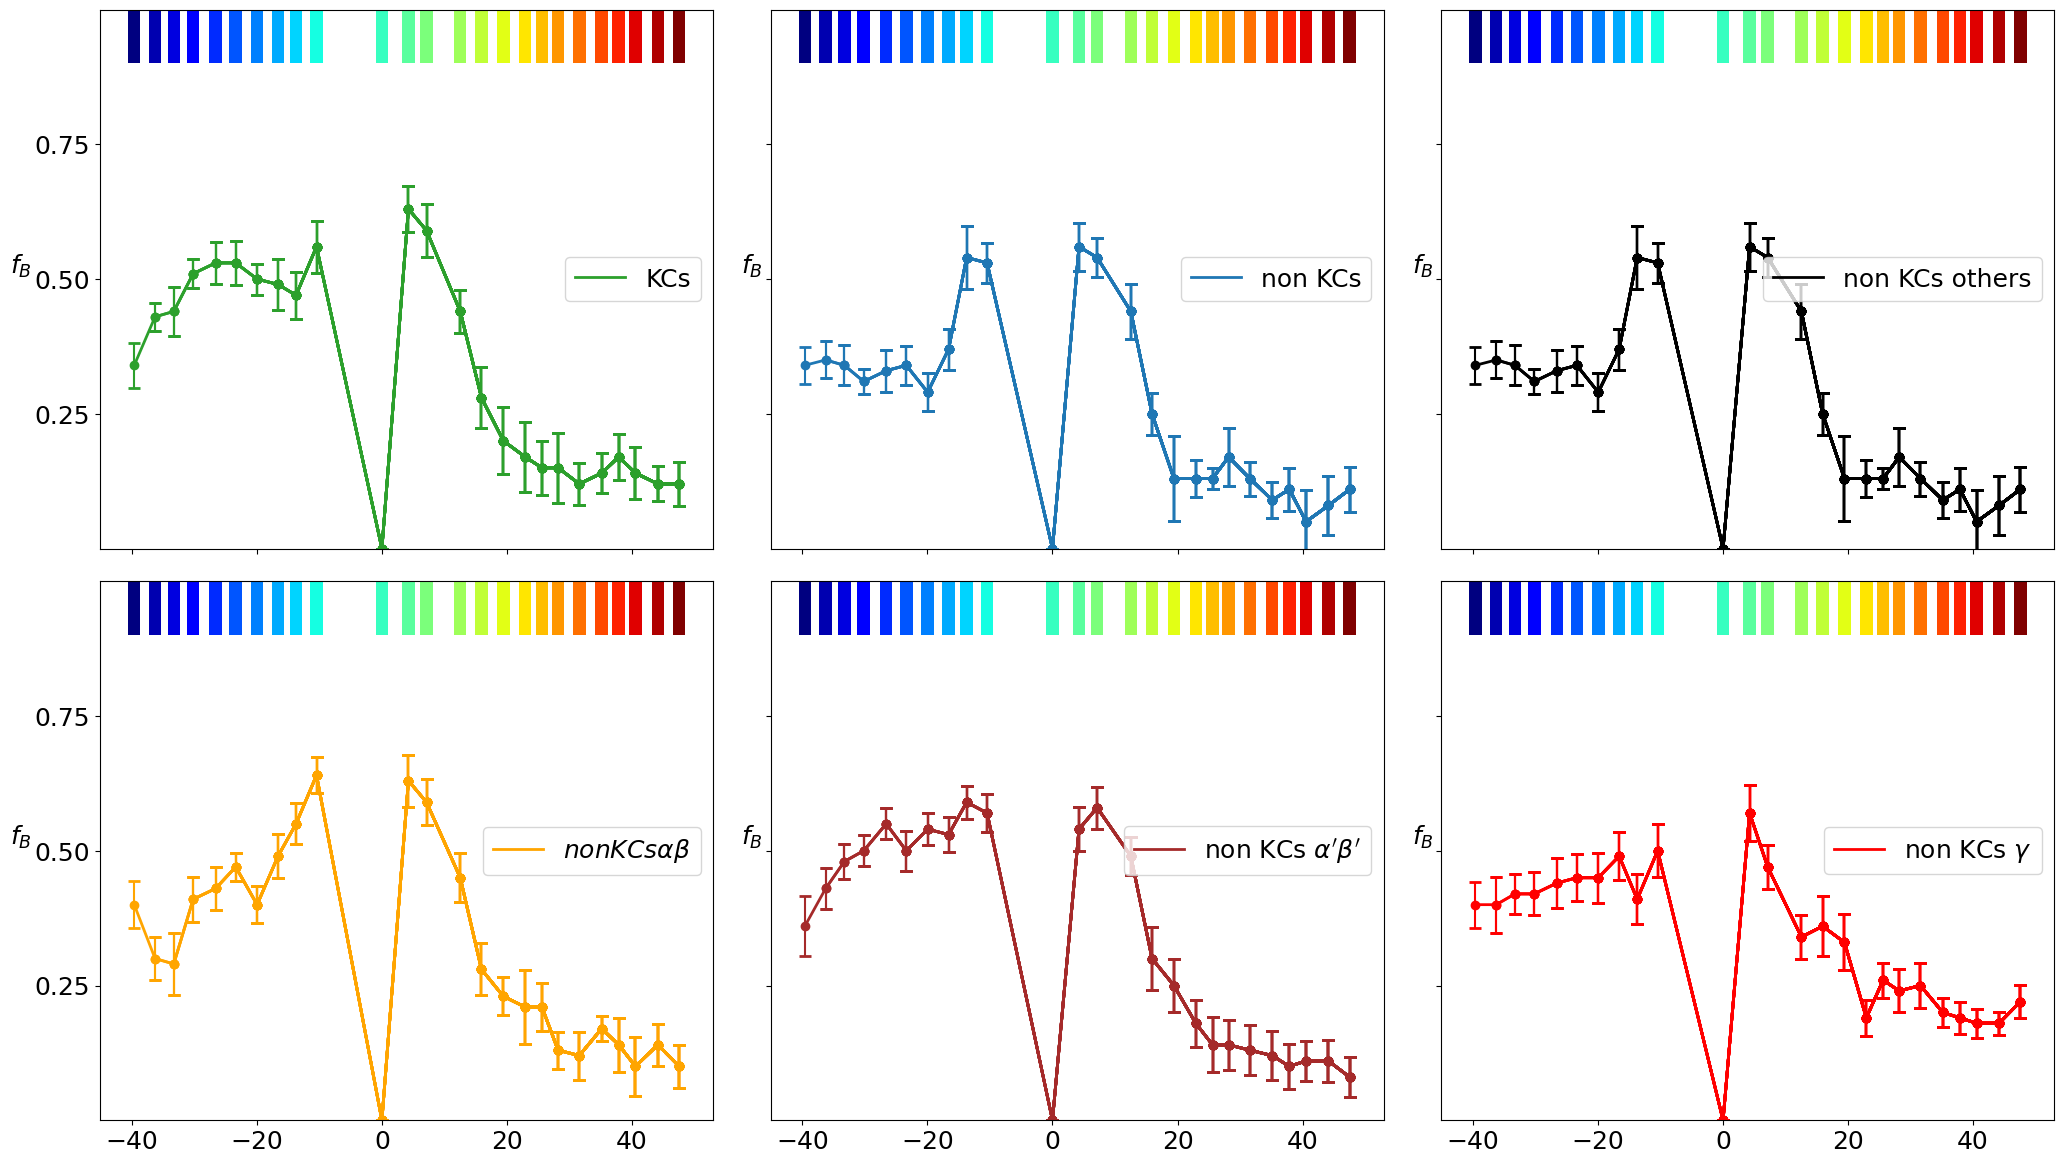

In [35]:

rut_prom_ref = r"$P_\text{rut}$"
plot_alpha_fraction_with_r2_inset(rut_RESULTS,  ['KCs','non KCs','non KCs others',r"$non KCs \alpha \beta$", r"non KCs $\alpha' \beta'$", r"non KCs $\gamma$"], rut_prom_ref)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_alpha_fraction_compare(RESULTS, cell_lines, ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())

    # Determine the type of tissues (sNPF or rut) based on the dictionary name
    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)
    else:
        raise ValueError('Invalid dictionary')

    fig, ax = plt.subplots(figsize=(8, 5))
    # plt.suptitle(f'{tissues_type}', fontsize=20, fontweight='bold', y=1.05)

    for cl, cell_line in enumerate(cell_lines):
        name = RESULTS[cell_line]['name']
        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']
        bc_position = RESULTS[cell_line]['bc_position']
        genomic_dist = RESULTS[cell_line]['genomic_dist']

        DRe1_matrix = RESULTS[cell_line]['DRe1_matrix']
        DRe2_matrix = RESULTS[cell_line]['DRe2_matrix']
        Dfr_matrix = RESULTS[cell_line]['Dfr_matrix']

        R_matrix = RESULTS[cell_line]['Unique_R']
        DR_matrix = RESULTS[cell_line]['DUnique_R']

        color = RESULTS[cell_line]['color']
        bc_color = RESULTS[cell_line]['bc_color']

        fa = fr_matrix[ref_bc, :]
        Re1 = Re1_matrix[ref_bc, :]
        Re2 = Re2_matrix[ref_bc, :]

        Dfa = Dfr_matrix[ref_bc, :]
        DRe1 = DRe1_matrix[ref_bc, :]
        DRe2 = DRe2_matrix[ref_bc, :]

        R_gauss = R_matrix[ref_bc, :]
        DR_gauss = DR_matrix[ref_bc, :]

        other_bc = [i for i in range(Re1_matrix.shape[0]) if i != ref_bc]
        fa_other = np.mean(fr_matrix[other_bc, :], axis=0)

        r2_two_phases_matrix = RESULTS[cell_line]['R_squared_matrix']
        r2_gauss_matrix = RESULTS[cell_line]['R_squared_gauss_matrix']
        r2_two_phases = r2_two_phases_matrix[ref_bc, :]
        r2_gauss = r2_gauss_matrix[ref_bc, :]

        upper_Re1 = Re1 + DRe1
        lower_Re1 = Re1 - DRe1
        upper_Re2 = Re2 + DRe2
        lower_Re2 = Re2 - DRe2

        upper_R = R_gauss + DR_gauss
        lower_R = R_gauss - DR_gauss

        condition = ((lower_Re1 >= lower_Re2) & (upper_Re1 <= upper_Re2)) | ((lower_Re2 >= lower_Re1) & (upper_Re2 <= upper_Re1)) | (((lower_R >= lower_Re1) & (upper_R <= upper_Re1 )) | ((R_gauss >= lower_Re2) & (R_gauss <= upper_Re2))) | (r2_two_phases - 0.07 < r2_gauss ) | (Dfa > 1/5)
        print(condition)
        condition = np.full(25, False)
        condition[10] = True

        bc_position = np.array([(i - bc_position[ref_bc])/1000 for i in bc_position])

        # Mask the data points where the condition is met
        mask = ~condition


        # Plot segments where mask is True
        for i in range(len(mask)):
            if mask[i]:
                start = i
                while i < len(mask) and mask[i]:
                    i += 1
                end = i
                ax.plot(bc_position[start:end], fa[start:end], linewidth=2, color=color, label=name if start == 0 else "")
                ax.errorbar(bc_position[start:end], fa[start:end], yerr=Dfa[start:end], fmt='o', color=color, ecolor=color, capsize=4, capthick=2)

        # ax.plot(bc_position, fa_other, linewidth=1, linestyle=':', color='k', label=r'$\langle vs. autres \rangle$')

    # ax.set_xlabel(r'$\Delta s~(kb)$', fontsize=18)
    ax.set_xlabel('Genomic distance', fontsize=18)
    ax.set_ylabel(r"Fraction of the bound state $f_B$", fontsize=18, rotation=90, rotation_mode='anchor', labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.bar(bc_position, 0.05, width=3, color=bc_color, linewidth=3.5, alpha=1, bottom=0.95)
    ax.legend(fontsize=18, loc='upper right')
    ax.tick_params(axis='both', which='both', labelsize=18)

    plt.tight_layout(pad=2.0)
    plt.savefig(f'{tissues_type}_alpha_fraction_compare.svg')
    plt.show()

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def plot_alpha_fraction_compare(RESULTS, cell_lines, ref_key):
    if cell_lines is None:
        cell_lines = list(RESULTS.keys())

    # Determine the type of tissues (sNPF or rut) based on the dictionary name
    if RESULTS is rut_RESULTS:
        tissues_type = 'rut'
        ref_bc = rut_bc_type.index(ref_key)
    else:
        raise ValueError('Invalid dictionary')

    fig, ax = plt.subplots(figsize=(8, 6))

    for cl, cell_line in enumerate(cell_lines):
        name = RESULTS[cell_line]['name']
        Re1_matrix = RESULTS[cell_line]['Re1_matrix']
        Re2_matrix = RESULTS[cell_line]['Re2_matrix']
        fr_matrix = RESULTS[cell_line]['fr_matrix']
        bc_position = RESULTS[cell_line]['bc_position']
        genomic_dist = RESULTS[cell_line]['genomic_dist']

        DRe1_matrix = RESULTS[cell_line]['DRe1_matrix']
        DRe2_matrix = RESULTS[cell_line]['DRe2_matrix']
        Dfr_matrix = RESULTS[cell_line]['Dfr_matrix']

        R_matrix = RESULTS[cell_line]['Unique_R']
        DR_matrix = RESULTS[cell_line]['DUnique_R']

        color = RESULTS[cell_line]['color']
        bc_color = RESULTS[cell_line]['bc_color']

        fa = fr_matrix[ref_bc, :]
        Re1 = Re1_matrix[ref_bc, :]
        Re2 = Re2_matrix[ref_bc, :]

        Dfa = Dfr_matrix[ref_bc, :]
        DRe1 = DRe1_matrix[ref_bc, :]
        DRe2 = DRe2_matrix[ref_bc, :]

        R_gauss = R_matrix[ref_bc, :]
        DR_gauss = DR_matrix[ref_bc, :]

        other_bc = [i for i in range(Re1_matrix.shape[0]) if i != ref_bc]
        fa_other = np.mean(fr_matrix[other_bc, :], axis=0)

        r2_two_phases_matrix = RESULTS[cell_line]['R_squared_matrix']
        r2_gauss_matrix = RESULTS[cell_line]['R_squared_gauss_matrix']
        r2_two_phases = r2_two_phases_matrix[ref_bc, :]
        r2_gauss = r2_gauss_matrix[ref_bc, :]

        upper_Re1 = Re1 + DRe1
        lower_Re1 = Re1 - DRe1
        upper_Re2 = Re2 + DRe2
        lower_Re2 = Re2 - DRe2

        upper_R = R_gauss + DR_gauss
        lower_R = R_gauss - DR_gauss

        condition = ((lower_Re1 >= lower_Re2) & (upper_Re1 <= upper_Re2)) | ((lower_Re2 >= lower_Re1) & (upper_Re2 <= upper_Re1)) | (((lower_R >= lower_Re1) & (upper_R <= upper_Re1 )) | ((R_gauss >= lower_Re2) & (R_gauss <= upper_Re2))) | (r2_two_phases - 0.07 < r2_gauss ) | (Dfa > 1/5)
        condition = np.full(25, False)
        condition[ref_bc] = True

        bc_position = np.array([(i - bc_position[ref_bc])/1000 for i in bc_position])

        # Mask the data points where the condition is met
        mask = ~condition

        # Plot segments where mask is True
        for i in range(len(mask)):
            if mask[i]:
                start = i
                while i < len(mask) and mask[i]:
                    i += 1
                end = i
                ax.plot(bc_position[start:end], fa[start:end], linewidth=2, color=color, label=name if start == 0 else "")
                ax.errorbar(bc_position[start:end], fa[start:end], yerr=Dfa[start:end], fmt='o', color=color, ecolor=color, capsize=4, capthick=2)

    ax.set_xlabel('Genomic distance (kb)', fontsize=20)
    ax.set_ylabel(r"Fraction of proximal state $f_B$", fontsize=20)
    ax.set_ylim(0, 1)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([0 , 0.25, 0.5, 0.75, 1])
    # ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    # ax.bar(bc_position, 0.05, width=3, color=bc_color, linewidth=3.5, alpha=1, bottom=0.95)
    ax.legend(fontsize=18, loc='upper right')
    ax.tick_params(axis='both', which='both', labelsize=18)

    plt.tight_layout(pad=2.0)
    # plt.savefig(f'{tissues_type}_alpha_fraction_compare_abp_nonKC.svg', dpi=300)
    plt.savefig('3E.svg', dpi=300)
    plt.show()

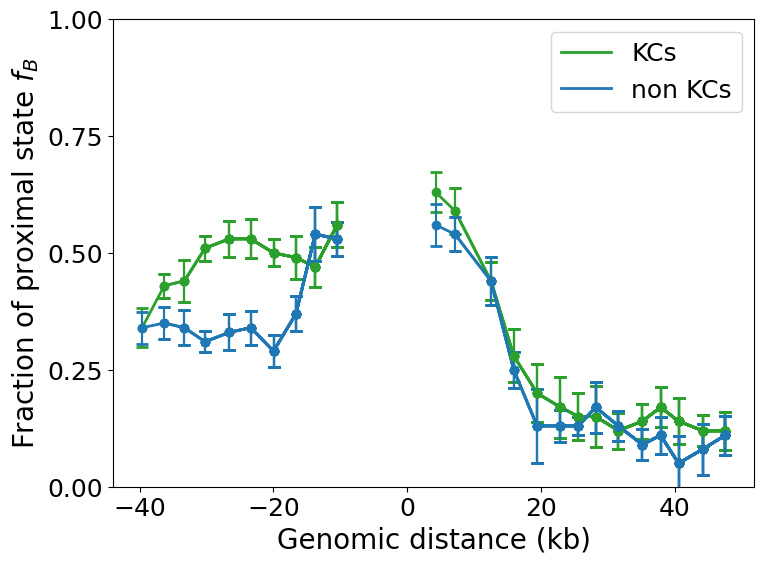

In [38]:
rut_prom_ref = r"$P_\text{rut}$"
# rut_prom_ref = 10
plot_alpha_fraction_compare(rut_RESULTS, ['KCs','non KCs'], rut_prom_ref)



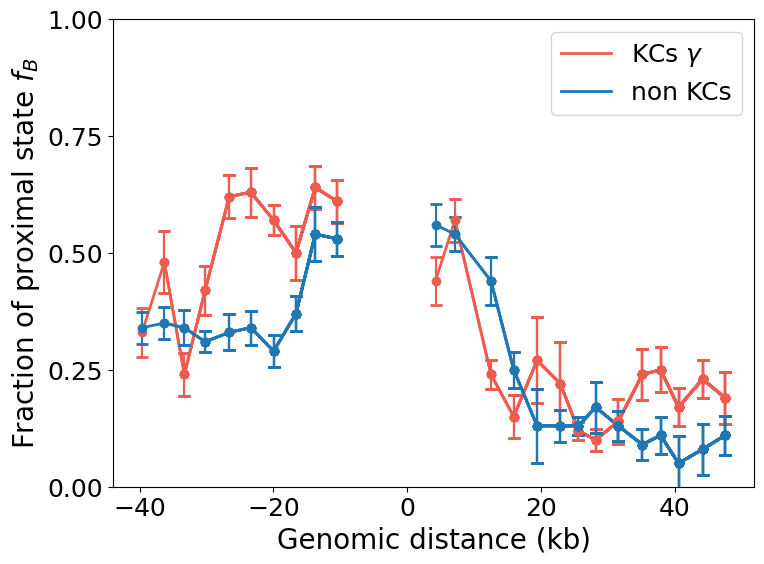

In [39]:
plot_alpha_fraction_compare(rut_RESULTS, [ r"KCs $\gamma$",'non KCs'], rut_prom_ref)

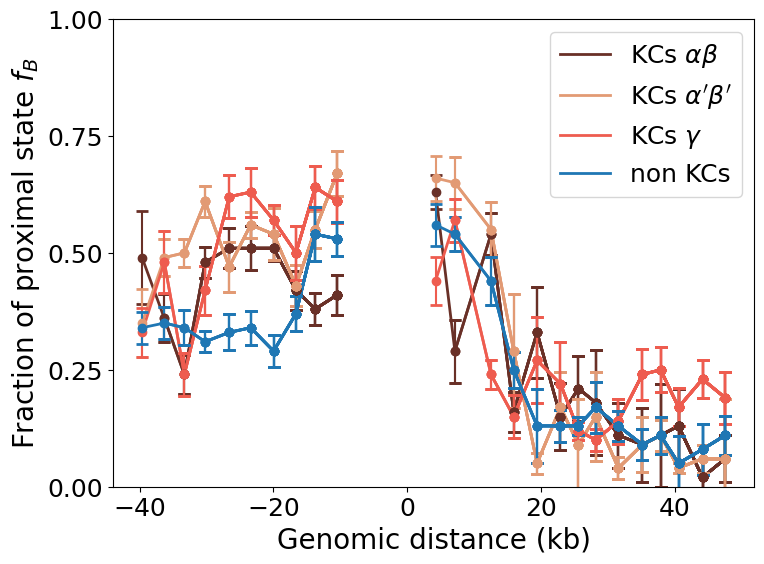

In [40]:
plot_alpha_fraction_compare(rut_RESULTS, [ r"KCs $\alpha \beta$", r"KCs $\alpha' \beta'$",r"KCs $\gamma$",'non KCs'], rut_prom_ref)

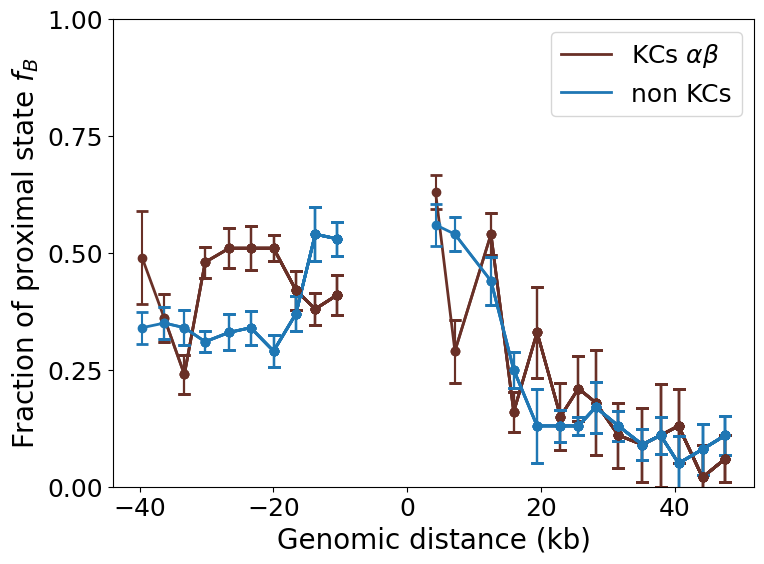

In [41]:
plot_alpha_fraction_compare(rut_RESULTS, [ r"KCs $\alpha \beta$",'non KCs'], rut_prom_ref)


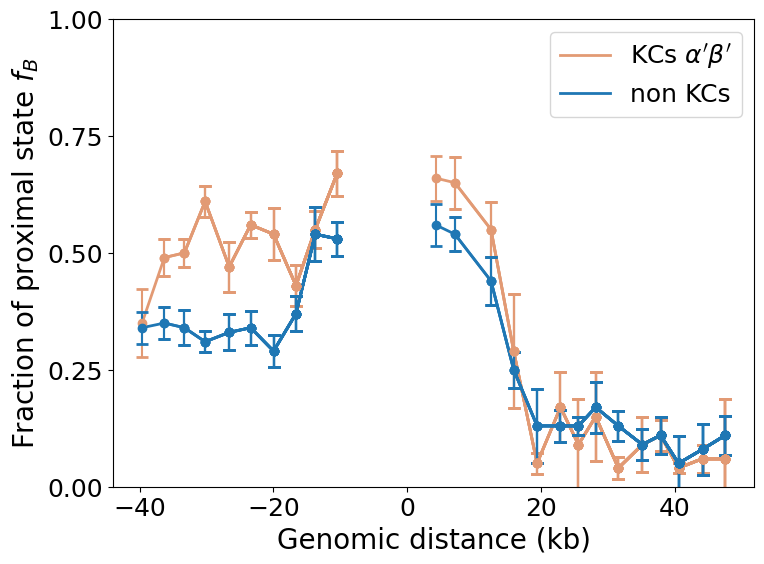

In [42]:
plot_alpha_fraction_compare(rut_RESULTS, [ r"KCs $\alpha' \beta'$",'non KCs'], rut_prom_ref)


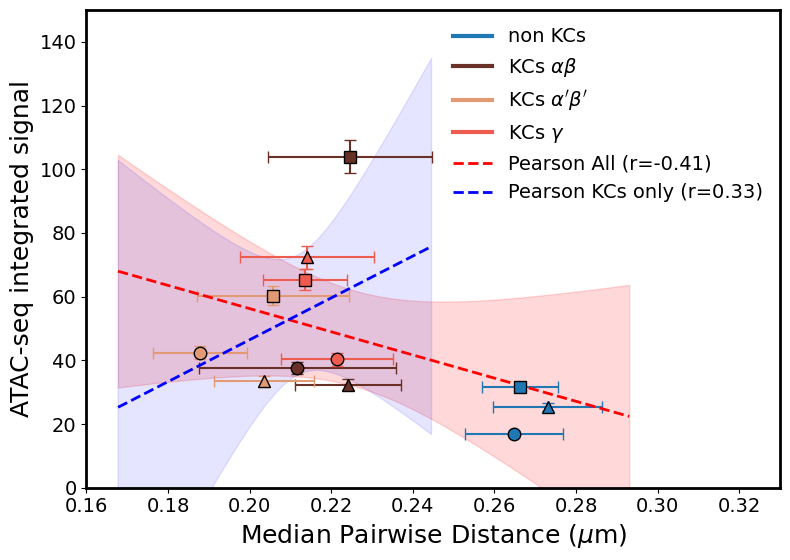

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =========================================================
# 1. DONNÉES ATAC-SEQ (Json fourni)
# =========================================================
data = {
  "points": [
    {"x": 0.21171091496944427, "y": 37.549293518066406, "xerr": 0.024148593749850983, "yerr": 1.8774646520614624, "cell_type": "AB", "region": "Rut_E1"},
    {"x": 0.18775098770856857, "y": 42.42685317993164, "xerr": 0.011516654212027785, "yerr": 2.121342658996582, "cell_type": "ABp", "region": "Rut_E1"},
    {"x": 0.2213100716471672, "y": 40.383358001708984, "xerr": 0.01372385025024414, "yerr": 2.019167900085449, "cell_type": "G", "region": "Rut_E1"},
    {"x": 0.26480020582675934, "y": 17.00628662109375, "xerr": 0.012123285979032533, "yerr": 0.8503143191337585, "cell_type": "not_KCs", "region": "Rut_E1"},
    {"x": 0.22459593415260315, "y": 103.86054229736328, "xerr": 0.02004031091928482, "yerr": 5.193027019500732, "cell_type": "AB", "region": "Rut_E1p"},
    {"x": 0.20579028129577637, "y": 60.29360580444336, "xerr": 0.01863272488117218, "yerr": 3.0146803855895996, "cell_type": "ABp", "region": "Rut_E1p"},
    {"x": 0.21365107595920563, "y": 65.35205078125, "xerr": 0.010254744440317154, "yerr": 3.2676026821136475, "cell_type": "G", "region": "Rut_E1p"},
    {"x": 0.2662333548069, "y": 31.55537223815918, "xerr": 0.009313578531146033, "yerr": 1.5777686834335327, "cell_type": "not_KCs", "region": "Rut_E1p"},
    {"x": 0.22401821613311768, "y": 32.40643310546875, "xerr": 0.012970678508281708, "yerr": 1.6203216314315796, "cell_type": "AB", "region": "Rut_E2"},
    {"x": 0.20351383090019226, "y": 33.37348937988281, "xerr": 0.012188762426376343, "yerr": 1.6686744689941406, "cell_type": "ABp", "region": "Rut_E2"},
    {"x": 0.2140485644340515, "y": 72.31372833251953, "xerr": 0.016485830023884776, "yerr": 3.6156864166259766, "cell_type": "G", "region": "Rut_E2"},
    {"x": 0.2730392962694168, "y": 25.476011276245117, "xerr": 0.013404497876763344, "yerr": 1.2738006114959717, "cell_type": "not_KCs", "region": "Rut_E2"}
  ],
  "all_r": -0.40849463565945177,
  "kc_r": 0.3252545629809994
}

# Mapping
custom_labels = {'not_KCs': 'non KCs', 'AB': r"KCs $\alpha \beta$", 'ABp': r"KCs $\alpha' \beta'$", 'G': r"KCs $\gamma$"}
custom_colors = {'not_KCs': 'tab:blue', 'AB': '#693027', 'ABp': '#E29A74', 'G': '#EE5C4F'}
marker_map = {"Rut_E1": 'o', "Rut_E1p": 's', "Rut_E2": '^'}

# Préparation X/Y
all_x = np.array([p['x'] for p in data['points']])
all_y = np.array([p['y'] for p in data['points']])
kc_pts = [p for p in data['points'] if p['cell_type'] != 'not_KCs']
kc_x = np.array([p['x'] for p in kc_pts])
kc_y = np.array([p['y'] for p in kc_pts])

# =========================================================
# 4. FIT LINEAIRE ET INTERVALLE DE CONFIANCE (CI)
# =========================================================
def compute_fit_and_ci(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_grid = np.linspace(np.min(x) - 0.02, np.max(x) + 0.02, 100)
    y_hat = intercept + slope * x_grid
    n = len(x)
    t_val = stats.t.ppf(0.975, n - 2)
    s_err = np.sqrt(np.sum((y - (intercept + slope * x))**2) / (n - 2))
    mean_x = np.mean(x)
    ss_xx = np.sum((x - mean_x)**2)
    ci = t_val * s_err * np.sqrt(1/n + (x_grid - mean_x)**2 / ss_xx)
    return x_grid, y_hat, ci

all_xgrid, all_yhat, all_ci = compute_fit_and_ci(all_x, all_y)
kc_xgrid, kc_yhat, kc_ci = compute_fit_and_ci(kc_x, kc_y)

# =========================================================
# 5. TRACÉ DE LA FIGURE 4E
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Tracé des points
for p in data['points']:
    ax.errorbar(p['x'], p['y'], xerr=p['xerr'], yerr=p['yerr'],
                fmt=marker_map[p['region']], color=custom_colors[p["cell_type"]],
                markersize=9, capsize=4, elinewidth=1.5, markeredgecolor='black')

# Tracé des fits ET des intervalles de confiance en transparence
ax.plot(all_xgrid, all_yhat, color='red', linestyle='--', lw=2)
ax.fill_between(all_xgrid, all_yhat - all_ci, all_yhat + all_ci, color='red', alpha=0.15)

ax.plot(kc_xgrid, kc_yhat, color='blue', linestyle='--', lw=2)
ax.fill_between(kc_xgrid, kc_yhat - kc_ci, kc_yhat + kc_ci, color='blue', alpha=0.10)

# Esthétique
ax.set_xlabel(r"Median Pairwise Distance ($\mu$m)", fontsize=18)
ax.set_ylabel("ATAC-seq integrated signal", fontsize=18)
ax.tick_params(axis='both', which='both', labelsize=14)

ax.set_ylim(0, 150)
ax.set_xlim(0.16, 0.33)

# --- LÉGENDE 1 : Enhancers (Horizontale en haut, STRICTEMENT COMME 4G) ---
handles_enh = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1$"),
               plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1'$"),
               plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r'$P_\text{rut}-E_2$')]

leg1 = ax.legend(handles=handles_enh, loc='upper center', bbox_to_anchor=(0.5, 1.15),
                 ncol=3, fontsize=14, frameon=False)
ax.add_artist(leg1)

# --- LÉGENDE 2 : Cellules/Pearson (STRICTEMENT COMME 4G) ---
handles_main = [plt.Line2D([0], [0], linestyle='-', lw=3, color=custom_colors[ct], label=custom_labels[ct])
                for ct in ['not_KCs', 'AB', 'ABp', 'G']]
handles_main.append(plt.Line2D([0], [0], color='red', linestyle='--', lw=2, label=f'Pearson All (r={data["all_r"]:.2f})'))
handles_main.append(plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'Pearson KCs only (r={data["kc_r"]:.2f})'))

ax.legend(handles=handles_main, fontsize=14, loc='best', frameon=False)

# Boxed
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# Maintien du rect pour garantir la même taille physique de l'axe que les autres figures
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig.savefig('4E.svg', format='svg', dpi=300, bbox_inches='tight')

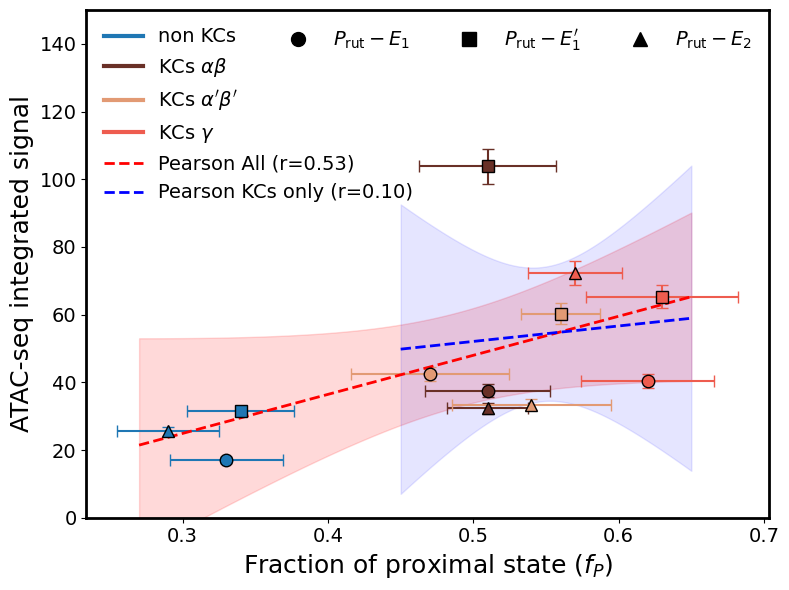

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =========================================================
# 1. DONNÉES ATAC-SEQ (Y) + CONFIGURATION
# =========================================================
data_atac = [
    {"cell_type": "not_KCs", "region": "Rut_E1",  "y": 17.00629,  "yerr": 0.85031},
    {"cell_type": "AB",      "region": "Rut_E1",  "y": 37.54929,  "yerr": 1.87746},
    {"cell_type": "ABp",     "region": "Rut_E1",  "y": 42.42685,  "yerr": 2.12134},
    {"cell_type": "G",       "region": "Rut_E1",  "y": 40.38336,  "yerr": 2.01917},
    {"cell_type": "not_KCs", "region": "Rut_E1p", "y": 31.55537,  "yerr": 1.57777},
    {"cell_type": "AB",      "region": "Rut_E1p", "y": 103.86054, "yerr": 5.19303},
    {"cell_type": "ABp",     "region": "Rut_E1p", "y": 60.29361,  "yerr": 3.01468},
    {"cell_type": "G",       "region": "Rut_E1p", "y": 65.35205,  "yerr": 3.26760},
    {"cell_type": "not_KCs", "region": "Rut_E2",  "y": 25.47601,  "yerr": 1.27380},
    {"cell_type": "AB",      "region": "Rut_E2",  "y": 32.40643,  "yerr": 1.62032},
    {"cell_type": "ABp",     "region": "Rut_E2",  "y": 33.37349,  "yerr": 1.66867},
    {"cell_type": "G",       "region": "Rut_E2",  "y": 72.31373,  "yerr": 3.61569}
]

# Mapping
region_to_enhancer = {"Rut_E1": r"$E_{1}$", "Rut_E1p": r"$E_{1'}$", "Rut_E2": r"$E_{2}$"}
celltype_to_results = {"not_KCs": 'non KCs others', "AB": r"KCs $\alpha \beta$", "ABp": r"KCs $\alpha' \beta'$", "G": r"KCs $\gamma$"}
custom_labels = {'not_KCs': 'non KCs', 'AB': r"KCs $\alpha \beta$", 'ABp': r"KCs $\alpha' \beta'$", 'G': r"KCs $\gamma$"}
custom_colors = {'not_KCs': 'tab:blue', 'AB': '#693027', 'ABp': '#E29A74', 'G': '#EE5C4F'}
marker_map = {"Rut_E1": 'o', "Rut_E1p": 's', "Rut_E2": '^'}

# =========================================================
# 2. EXTRACTION DE f_P (X) ET DE SON ERREUR
# =========================================================
prut_idx = rut_bc_type.index(r"$P_\text{rut}$")
all_x, all_y, kc_x, kc_y = [], [], [], []
all_xerr, all_yerr = [], []

for p in data_atac:
    cl_key = celltype_to_results[p["cell_type"]]
    enh_label = region_to_enhancer[p["region"]]
    enh_idx = rut_bc_type.index(enh_label)

    # Extraction f_P et df_P depuis le modèle
    f_p = rut_RESULTS[cl_key]['fr_matrix'][prut_idx, enh_idx]
    df_p = rut_RESULTS[cl_key]['Dfr_matrix'][prut_idx, enh_idx]

    all_x.append(f_p)
    all_y.append(p["y"])
    all_xerr.append(df_p)
    all_yerr.append(p["yerr"])

    if p["cell_type"] != "not_KCs":
        kc_x.append(f_p)
        kc_y.append(p["y"])

all_x, all_y = np.array(all_x), np.array(all_y)
all_xerr, all_yerr = np.array(all_xerr), np.array(all_yerr)
kc_x, kc_y = np.array(kc_x), np.array(kc_y)

# =========================================================
# 3. FIT LINÉAIRE ET INTERVALLE DE CONFIANCE (CI)
# =========================================================
def compute_fit_and_ci(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_grid = np.linspace(np.min(x) - 0.02, np.max(x) + 0.02, 100)
    y_hat = intercept + slope * x_grid
    n = len(x)
    t_val = stats.t.ppf(0.975, n - 2)
    s_err = np.sqrt(np.sum((y - (intercept + slope * x))**2) / (n - 2))
    mean_x = np.mean(x)
    ss_xx = np.sum((x - mean_x)**2)
    ci = t_val * s_err * np.sqrt(1/n + (x_grid - mean_x)**2 / ss_xx)
    return x_grid, y_hat, ci, r_value, p_value

all_xgrid, all_yhat, all_ci, all_r, all_p = compute_fit_and_ci(all_x, all_y)
kc_xgrid, kc_yhat, kc_ci, kc_r, kc_p = compute_fit_and_ci(kc_x, kc_y)

# =========================================================
# 4. TRACÉ DE LA FIGURE (ATAC vs f_P)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Tracé des points
for i, p in enumerate(data_atac):
    ax.errorbar(all_x[i], all_y[i],
                xerr=all_xerr[i], yerr=all_yerr[i],
                fmt=marker_map[p['region']], color=custom_colors[p["cell_type"]],
                markersize=9, capsize=4, elinewidth=1.5, markeredgecolor='black')

# Tracé des fits
ax.plot(all_xgrid, all_yhat, color='red', linestyle='--', lw=2)
ax.fill_between(all_xgrid, all_yhat - all_ci, all_yhat + all_ci, color='red', alpha=0.15)

ax.plot(kc_xgrid, kc_yhat, color='blue', linestyle='--', lw=2)
ax.fill_between(kc_xgrid, kc_yhat - kc_ci, kc_yhat + kc_ci, color='blue', alpha=0.10)

# Esthétique
ax.set_xlabel(r"Fraction of proximal state ($f_P$)", fontsize=18)
ax.set_ylabel("ATAC-seq integrated signal", fontsize=18)
ax.tick_params(axis='both', which='both', labelsize=14)

ax.set_ylim(0, 150)

# --- LÉGENDE 1 : Enhancers (Horizontale, en haut à droite DANS le cadre) ---
handles_enh = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1$"),
               plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1'$"),
               plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r'$P_\text{rut}-E_2$')]
leg1 = ax.legend(handles=handles_enh, loc='upper right', ncol=3, fontsize=14, frameon=False)
ax.add_artist(leg1)

# --- LÉGENDE 2 : Cellules/Pearson (En haut à gauche DANS le cadre) ---
handles_main = [plt.Line2D([0], [0], linestyle='-', lw=3, color=custom_colors[ct], label=custom_labels[ct]) for ct in ['not_KCs', 'AB', 'ABp', 'G']]
handles_main.append(plt.Line2D([0], [0], color='red', linestyle='--', lw=2, label=f'Pearson All (r={all_r:.2f})'))
handles_main.append(plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'Pearson KCs only (r={kc_r:.2f})'))

ax.legend(handles=handles_main, fontsize=14, loc='upper left', frameon=False)

# Boxed
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# Plus besoin du `rect` puisqu'on est dans le cadre
plt.tight_layout()
plt.show()

fig.savefig('ATAC_vs_fP.svg', format='svg', dpi=300, bbox_inches='tight')

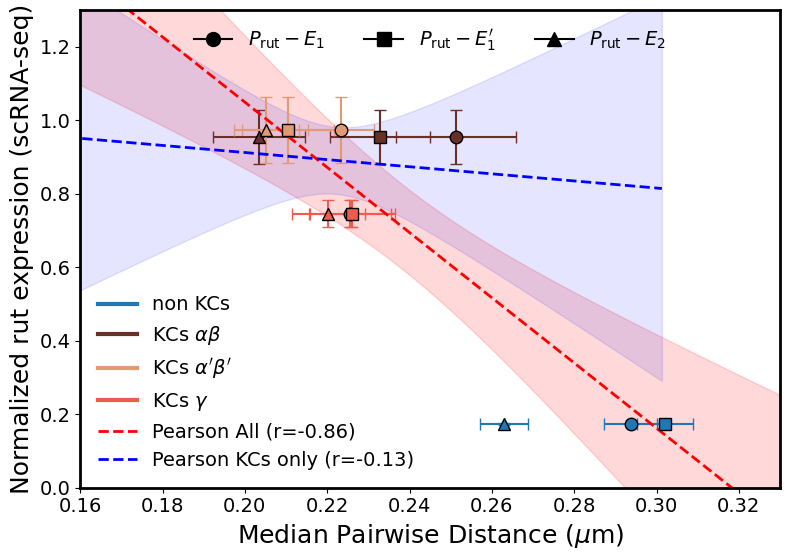

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =========================================================
# 1. DONNÉES D'OLIVIER (Valeurs Y : RNA/ATAC)
# =========================================================
# On garde les structures, mais on va recalculer les X (distances)
olivier_points = [
    {"cell_type": "not_KCs", "region": "Rut_E1", "y": 0.17282, "yerr": 0.00322},
    {"cell_type": "AB",      "region": "Rut_E1", "y": 0.95380, "yerr": 0.07341},
    {"cell_type": "ABp",     "region": "Rut_E1", "y": 0.97307, "yerr": 0.08967},
    {"cell_type": "G",       "region": "Rut_E1", "y": 0.74565, "yerr": 0.03714},
    {"cell_type": "not_KCs", "region": "Rut_E1p","y": 0.17282, "yerr": 0.00322},
    {"cell_type": "AB",      "region": "Rut_E1p","y": 0.95380, "yerr": 0.07341},
    {"cell_type": "ABp",     "region": "Rut_E1p","y": 0.97307, "yerr": 0.08967},
    {"cell_type": "G",       "region": "Rut_E1p","y": 0.74565, "yerr": 0.03714},
    {"cell_type": "not_KCs", "region": "Rut_E2", "y": 0.17282, "yerr": 0.00322},
    {"cell_type": "AB",      "region": "Rut_E2", "y": 0.95380, "yerr": 0.07341},
    {"cell_type": "ABp",     "region": "Rut_E2", "y": 0.97307, "yerr": 0.08967},
    {"cell_type": "G",       "region": "Rut_E2", "y": 0.74565, "yerr": 0.03714}
]

region_to_enhancer = {"Rut_E1": r"$E_{1}$", "Rut_E1p": r"$E_{1'}$", "Rut_E2": r"$E_{2}$"}
celltype_to_results = {
    "not_KCs": 'non KCs others',
    "AB": r"KCs $\alpha \beta$",
    "ABp": r"KCs $\alpha' \beta'$",
    "G": r"KCs $\gamma$"
}

custom_labels = {
    'not_KCs': 'non KCs',
    'AB': r"KCs $\alpha \beta$",
    'ABp': r"KCs $\alpha' \beta'$",
    'G': r"KCs $\gamma$"
}

custom_colors = {
    'not_KCs': 'tab:blue',
    'AB': '#693027',
    'ABp': '#E29A74',
    'G': '#EE5C4F'
}

# =========================================================
# 3. EXTRACTION DES DISTANCES MÉDIANES (vs Distance)
# =========================================================
prut_idx = rut_bc_type.index(r"$P_\text{rut}$")
all_x, all_y = [], []
all_xerr, all_yerr = [], []
kc_x, kc_y = [], []

for p in olivier_points:
    cl_key = celltype_to_results[p["cell_type"]]
    enh_label = region_to_enhancer[p["region"]]
    enh_idx = rut_bc_type.index(enh_label)

    # Calcul de la distance médiane et de l'incertitude (Standard Error of Median approximation)
    dist_data = rut_RESULTS[cl_key]['distmat'][prut_idx, enh_idx, :]
    median_dist = np.nanmedian(dist_data)
    # On utilise l'écart-type pour représenter la dispersion de la distribution de distance
    std_dist = np.nanstd(dist_data) / np.sqrt(np.sum(~np.isnan(dist_data)))

    all_x.append(median_dist)
    all_y.append(p["y"])
    all_xerr.append(std_dist)
    all_yerr.append(p["yerr"])

    if p["cell_type"] != "not_KCs":
        kc_x.append(median_dist)
        kc_y.append(p["y"])

all_x, all_y, all_xerr, all_yerr = np.array(all_x), np.array(all_y), np.array(all_xerr), np.array(all_yerr)
kc_x, kc_y = np.array(kc_x), np.array(kc_y)

# Fit linéaire
def compute_fit_and_ci(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_grid = np.linspace(np.min(x) - 0.05, np.max(x) + 0.05, 100)
    y_hat = intercept + slope * x_grid
    n = len(x)
    t_val = stats.t.ppf(0.975, n - 2)
    s_err = np.sqrt(np.sum((y - (intercept + slope * x))**2) / (n - 2))
    mean_x = np.mean(x)
    ss_xx = np.sum((x - mean_x)**2)
    ci = t_val * s_err * np.sqrt(1/n + (x_grid - mean_x)**2 / ss_xx)
    return x_grid, y_hat, ci, r_value, p_value

all_xgrid, all_yhat, all_ci, all_r, all_p = compute_fit_and_ci(all_x, all_y)
kc_xgrid, kc_yhat, kc_ci, kc_r, kc_p = compute_fit_and_ci(kc_x, kc_y)

# =========================================================
# 5. TRACÉ DE LA FIGURE 4F (Boxed)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))

marker_map = {"Rut_E1": 'o', "Rut_E1p": 's', "Rut_E2": '^'}

for i, p in enumerate(olivier_points):
    ax.errorbar(all_x[i], all_y[i],
                xerr=all_xerr[i], yerr=all_yerr[i],
                fmt=marker_map[p['region']], color=custom_colors[p["cell_type"]],
                markersize=9, capsize=4, elinewidth=1.5, markeredgecolor='black')

ax.plot(all_xgrid, all_yhat, color='red', linestyle='--', lw=2)
ax.fill_between(all_xgrid, all_yhat - all_ci, all_yhat + all_ci, color='red', alpha=0.15)
ax.plot(kc_xgrid, kc_yhat, color='blue', linestyle='--', lw=2)
ax.fill_between(kc_xgrid, kc_yhat - kc_ci, kc_yhat + kc_ci, color='blue', alpha=0.10)

ax.set_xlabel(r"Median Pairwise Distance ($\mu$m)", fontsize=18)
ax.set_ylabel("Normalized rut expression (scRNA-seq)", fontsize=18)
ax.tick_params(axis='both', which='both', labelsize=14)

ax.set_xlim(0.16, 0.33)
ax.set_ylim(0, 1.3)

# --- LÉGENDE 1 : Enhancers (Horizontale en haut) ---
handles_enh = [plt.Line2D([0], [0], marker='o', color='k', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1$"),
               plt.Line2D([0], [0], marker='s', color='k', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1'$"),
               plt.Line2D([0], [0], marker='^', color='k', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r'$P_\text{rut}-E_2$')]

leg1 = ax.legend(handles=handles_enh, loc='upper center',
                 ncol=3, fontsize=14, frameon=False)
ax.add_artist(leg1) # Indispensable pour garder cette légende avant d'en créer une autre

# --- LÉGENDE 2 : Cellules et Fit (Automatique) ---
handles_main = [plt.Line2D([0], [0], linestyle='-', lw=3, color=custom_colors[ct], label=custom_labels[ct])
                for ct in ['not_KCs', 'AB', 'ABp', 'G']]
handles_main.append(plt.Line2D([0], [0], color='red', linestyle='--', lw=2, label=f'Pearson All (r={all_r:.2f})'))
handles_main.append(plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'Pearson KCs only (r={kc_r:.2f})'))

ax.legend(handles=handles_main, fontsize=14, loc='best', frameon=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig.savefig('4F.svg', format='svg', dpi=300, bbox_inches='tight')

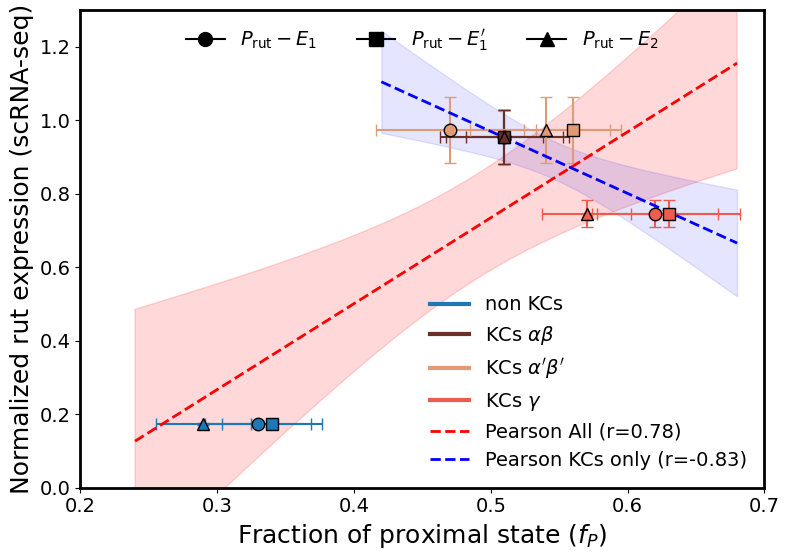

--- Analyse Statistique ---
Pearson All: r=0.7809, p=2.7168e-03
Pearson KCs only: r=-0.8286, p=5.7825e-03


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =========================================================
# 1. DONNÉES D'OLIVIER (Valeurs Y : RNA/ATAC)
# =========================================================
olivier_points = [
    {"cell_type": "not_KCs", "region": "Rut_E1", "y": 0.17282, "yerr": 0.00322},
    {"cell_type": "AB",      "region": "Rut_E1", "y": 0.95380, "yerr": 0.07341},
    {"cell_type": "ABp",     "region": "Rut_E1", "y": 0.97307, "yerr": 0.08967},
    {"cell_type": "G",       "region": "Rut_E1", "y": 0.74565, "yerr": 0.03714},
    {"cell_type": "not_KCs", "region": "Rut_E1p","y": 0.17282, "yerr": 0.00322},
    {"cell_type": "AB",      "region": "Rut_E1p","y": 0.95380, "yerr": 0.07341},
    {"cell_type": "ABp",     "region": "Rut_E1p","y": 0.97307, "yerr": 0.08967},
    {"cell_type": "G",       "region": "Rut_E1p","y": 0.74565, "yerr": 0.03714},
    {"cell_type": "not_KCs", "region": "Rut_E2", "y": 0.17282, "yerr": 0.00322},
    {"cell_type": "AB",      "region": "Rut_E2", "y": 0.95380, "yerr": 0.07341},
    {"cell_type": "ABp",     "region": "Rut_E2", "y": 0.97307, "yerr": 0.08967},
    {"cell_type": "G",       "region": "Rut_E2", "y": 0.74565, "yerr": 0.03714}
]

region_to_enhancer = {"Rut_E1": r"$E_{1}$", "Rut_E1p": r"$E_{1'}$", "Rut_E2": r"$E_{2}$"}
celltype_to_results = {
    "not_KCs": 'non KCs others',
    "AB": r"KCs $\alpha \beta$",
    "ABp": r"KCs $\alpha' \beta'$",
    "G": r"KCs $\gamma$"
}

custom_labels = {
    'not_KCs': 'non KCs',
    'AB': r"KCs $\alpha \beta$",
    'ABp': r"KCs $\alpha' \beta'$",
    'G': r"KCs $\gamma$"
}

custom_colors = {
    'not_KCs': 'tab:blue',
    'AB': '#693027',
    'ABp': '#E29A74',
    'G': '#EE5C4F'
}

# =========================================================
# 3. EXTRACTION DE f_P ET DE SON ERREUR
# =========================================================
prut_idx = rut_bc_type.index(r"$P_\text{rut}$")
all_x, all_y, kc_x, kc_y = [], [], [], []
all_xerr, all_yerr = [], []

for p in olivier_points:
    cl_key = celltype_to_results[p["cell_type"]]
    enh_label = region_to_enhancer[p["region"]]
    enh_idx = rut_bc_type.index(enh_label)

    f_p = rut_RESULTS[cl_key]['fr_matrix'][prut_idx, enh_idx]
    df_p = rut_RESULTS[cl_key]['Dfr_matrix'][prut_idx, enh_idx]

    all_x.append(f_p)
    all_y.append(p["y"])
    all_xerr.append(df_p)
    all_yerr.append(p["yerr"])

    if p["cell_type"] != "not_KCs":
        kc_x.append(f_p)
        kc_y.append(p["y"])

all_x, all_y, all_xerr, all_yerr = np.array(all_x), np.array(all_y), np.array(all_xerr), np.array(all_yerr)
kc_x, kc_y = np.array(kc_x), np.array(kc_y)

def compute_fit_and_ci(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_grid = np.linspace(np.min(x) - 0.05, np.max(x) + 0.05, 100)
    y_hat = intercept + slope * x_grid
    n = len(x)
    t_val = stats.t.ppf(0.975, n - 2)
    s_err = np.sqrt(np.sum((y - (intercept + slope * x))**2) / (n - 2))
    mean_x = np.mean(x)
    ss_xx = np.sum((x - mean_x)**2)
    ci = t_val * s_err * np.sqrt(1/n + (x_grid - mean_x)**2 / ss_xx)
    return x_grid, y_hat, ci, r_value, p_value

all_xgrid, all_yhat, all_ci, all_r, all_p = compute_fit_and_ci(all_x, all_y)
kc_xgrid, kc_yhat, kc_ci, kc_r, kc_p = compute_fit_and_ci(kc_x, kc_y)

# =========================================================
# 5. TRACÉ DE LA FIGURE (Avec deux légendes séparées)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Mapping pour les formes des marqueurs par enhancer
marker_map = {"Rut_E1": 'o', "Rut_E1p": 's', "Rut_E2": '^'}

# Tracé des points expérimentaux
for i, p in enumerate(olivier_points):
    marker = marker_map[p['region']]
    ax.errorbar(all_x[i], all_y[i],
                xerr=all_xerr[i], yerr=all_yerr[i],
                fmt=marker, color=custom_colors[p["cell_type"]],
                markersize=9, capsize=4, elinewidth=1.5, markeredgecolor='black')

# Fit global et KCs
ax.plot(all_xgrid, all_yhat, color='red', linestyle='--', lw=2)
ax.fill_between(all_xgrid, all_yhat - all_ci, all_yhat + all_ci, color='red', alpha=0.15)
ax.plot(kc_xgrid, kc_yhat, color='blue', linestyle='--', lw=2)
ax.fill_between(kc_xgrid, kc_yhat - kc_ci, kc_yhat + kc_ci, color='blue', alpha=0.10)

# Esthétique
ax.set_xlabel(r"Fraction of proximal state ($f_P$)", fontsize=18)
ax.set_ylabel("Normalized rut expression (scRNA-seq)", fontsize=18)
ax.tick_params(axis='both', which='both', labelsize=14)


ax.set_xlim(0.2, 0.7)
ax.set_ylim(0, 1.3)
# --- LÉGENDE 1 : Enhancers (Horizontale en haut) ---
handles_enh = [plt.Line2D([0], [0], marker='o', color='k', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1$"),
               plt.Line2D([0], [0], marker='s', color='k', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r"$P_\text{rut}-E_1'$"),
               plt.Line2D([0], [0], marker='^', color='k', markerfacecolor='k', markersize=10, markeredgecolor='k', label=r'$P_\text{rut}-E_2$')]

leg1 = ax.legend(handles=handles_enh, loc='upper center',
                 ncol=3, fontsize=14, frameon=False)
ax.add_artist(leg1) # Indispensable pour garder cette légende avant d'en créer une autre

# --- LÉGENDE 2 : Cellules et Fit (Automatique) ---
handles_main = [plt.Line2D([0], [0], linestyle='-', lw=3, color=custom_colors[ct], label=custom_labels[ct])
                for ct in ['not_KCs', 'AB', 'ABp', 'G']]
handles_main.append(plt.Line2D([0], [0], color='red', linestyle='--', lw=2, label=f'Pearson All (r={all_r:.2f})'))
handles_main.append(plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'Pearson KCs only (r={kc_r:.2f})'))

ax.legend(handles=handles_main, fontsize=14, loc='best', frameon=False)

# BOXED
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # On laisse un peu d'espace en haut pour la leg1
plt.show()

# Enregistrement
fig.savefig('4G.svg', format='svg', dpi=300, bbox_inches='tight')

# =========================================================
# 6. AFFICHAGE DES VALEURS P DANS LA CONSOLE
# =========================================================
print("--- Analyse Statistique ---")
print(f"Pearson All: r={all_r:.4f}, p={all_p:.4e}")
print(f"Pearson KCs only: r={kc_r:.4f}, p={kc_p:.4e}")

# Puis le reste...
plt.show()